# AXA-PRISM: Predictive Risk Intelligence & Strategic Mitigation
## Fase 2: Modeling, Evaluation & Decision Engine (CRISP-DM)

---

**Konteks Bisnis:**
Kenaikan klaim kesehatan 25,5 persen YoY memerlukan sistem cerdas yang mampu
menjawab dua pertanyaan utama: (1) *Berapa biaya yang seharusnya terjadi?* dan
(2) *Mengapa biaya aktual menyimpang dari ekspektasi?*

**Arsitektur AXA-PRISM Fase 2 terdiri dari dua lapisan:**

**Lapisan A - Modern Hybrid AI:**
- Random Forest Regressor untuk menghitung Expected Cost
- Isolation Forest untuk Anomaly Scoring pada deviasi biaya
- K-Means Clustering untuk segmentasi pola risiko

**Lapisan B - Traditional Expert System (Komparator):**
- Forward Chaining berbasis aturan IF-THEN
- Backward Chaining untuk goal-driven audit medis
- Teorema Bayes untuk probabilitas posterior High-Risk
- Certainty Factors untuk penanganan ketidakpastian pakar

**Output Akhir:** Role-Based Dashboard untuk Data Operator, Risk Analyst, Medical Auditor, dan Strategic Manager.


---
## Sel 1: Setup Lingkungan dan Konfigurasi Global

**Tujuan:** Memuat semua library, mendefinisikan konstanta global, dan mengonfigurasi
parameter pemodelan yang akan digunakan secara konsisten di seluruh notebook.

In [1]:
# --- Library Inti ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
import json
from collections import defaultdict
from datetime import datetime

In [6]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler # Tambahkan baris ini

In [2]:
# ================================================================
# SEL 1: SETUP LINGKUNGAN DAN KONFIGURASI GLOBAL
# ================================================================

# Instalasi package tambahan (aktifkan jika di Colab)
# !pip install xgboost scikit-learn pandas numpy matplotlib seaborn scipy -q



# --- Machine Learning ---
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, confusion_matrix, silhouette_score,
    roc_auc_score, roc_curve
)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.inspection import permutation_importance

# XGBoost tersedia di Colab secara default
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print("XGBoost tersedia:", xgb.__version__)
except ImportError:
    XGB_AVAILABLE = False
    print("XGBoost tidak tersedia, menggunakan Random Forest saja.")

# --- Konfigurasi Tampilan ---
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# ================================================================
# KONSTANTA GLOBAL AXA-PRISM
# ================================================================

RANDOM_STATE       = 42          # Seed untuk reproduktibilitas
TEST_SIZE          = 0.20        # 80/20 split
TIER1_PERCENTILE   = 90          # Ambang batas Tier-1 Critical (P90)
TIER2_PERCENTILE   = 75          # Ambang batas Tier-2 High Risk (P75)
N_CLUSTERS         = 4           # Jumlah cluster K-Means
IF_CONTAMINATION   = 0.10        # Estimasi proporsi anomali (10%)
N_ESTIMATORS_RF    = 200         # Jumlah pohon Random Forest
CURRENCY_UNIT      = 'IDR (Juta)'# Label mata uang untuk visualisasi

# Palet warna konsisten AXA-PRISM
COLOR_PALETTE = {
    'primary'  : '#0047AB',  # Biru AXA
    'danger'   : '#E63946',  # Merah risiko tinggi
    'warning'  : '#F4A261',  # Oranye peringatan
    'success'  : '#2A9D8F',  # Hijau normal
    'neutral'  : '#6C757D',  # Abu-abu netral
    'clusters' : ['#0047AB', '#E63946', '#F4A261', '#2A9D8F', '#9B59B6', '#1ABC9C']
}

print("=" * 60)
print("  AXA-PRISM Phase 2: Modeling Engine")
print("  Konfigurasi global berhasil dimuat.")
print("=" * 60)
print(f"  Random State  : {RANDOM_STATE}")
print(f"  Test Size     : {TEST_SIZE * 100:.0f}%")
print(f"  Tier-1 P-tile : P{TIER1_PERCENTILE}")
print(f"  K-Means K     : {N_CLUSTERS}")
print(f"  IF Contamin.  : {IF_CONTAMINATION * 100:.0f}%")

XGBoost tidak tersedia, menggunakan Random Forest saja.
  AXA-PRISM Phase 2: Modeling Engine
  Konfigurasi global berhasil dimuat.
  Random State  : 42
  Test Size     : 20%
  Tier-1 P-tile : P90
  K-Means K     : 4
  IF Contamin.  : 10%


---
## Sel 2: Loading Data dan Persiapan Fitur

**Tujuan:** Memuat `AXA_Prepared_Data.csv`, memvalidasi integritas kolom, dan
mendefinisikan set fitur yang akan digunakan oleh masing-masing algoritma.

Dataset dimuat: 4,627 baris x 57 kolom

--- Verifikasi Ketersediaan Fitur ---
Fitur Regression : 0/16 tersedia
Fitur Anomaly    : 0/13 tersedia

--- Statistik Target Variable ---
count            4,627.00
mean        59,949,398.03
std        159,783,760.49
min                  0.00
25%          2,720,209.50
50%         15,871,000.00
75%         54,230,667.53
max      3,892,809,996.00
Name: Nominal Biaya RS Yang Terjadi, dtype: object


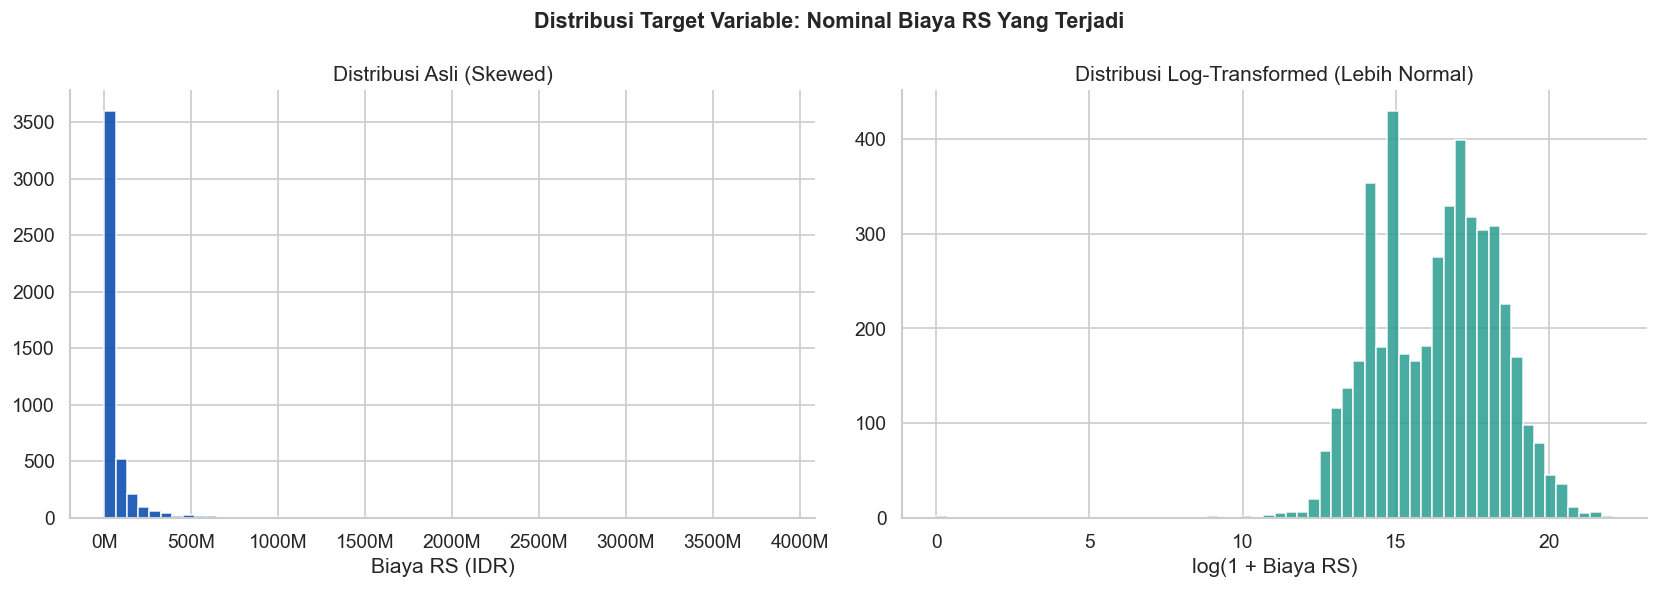


[KEPUTUSAN] Target akan dilatih dalam skala log1p untuk stabilitas regresi,
           kemudian dikembalikan ke skala asli dengan expm1 saat prediksi.


In [ ]:
# ================================================================
# SEL 2: LOADING DATA DAN DEFINISI FITUR
# ================================================================

df = pd.read_csv('D:\SEMESTER 6\PBL\Model-Comparison\dataset\AXA_Prepared_Data.csv')
print(f"Dataset dimuat: {df.shape[0]:,} baris x {df.shape[1]} kolom")

# --- Pastikan tipe numerik benar ---
numeric_cast = [
    'Nominal Klaim Yang Disetujui', 'Nominal Biaya RS Yang Terjadi',
    'Patient_Age', 'Policy_Tenure_Days', 'Claim_Frequency',
    'Cost_Gap', 'Cost_Gap_Ratio', 'Treatment_Duration',
    'Days_To_Payment', 'Lokasi_RS_Risk_Score',
    'Nominal Klaim Yang Disetujui_Scaled',
    'Nominal Biaya RS Yang Terjadi_Scaled',
    'Cost_Gap_Scaled', 'Patient_Age_Scaled',
    'Policy_Tenure_Days_Scaled', 'Treatment_Duration_Scaled',
    'Claim_Frequency_Scaled',
    'Gender_Encoded', 'Reimburse_Encoded', 'Care_Type_Encoded',
    'Plan_Code_Encoded', 'Domisili_Freq_Encoded',
    'Lokasi_RS_Freq_Encoded', 'ICD_Category_Encoded',
    'High_Value_Claim_Flag', 'New_Policy_Claim_Flag',
    'ICD_Category_Enc', 'Is_Overseas',
    'Is_Inpatient', 'Month_Claim', 'Quarter_Claim', 'Year_Claim'
]
for col in numeric_cast:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df.fillna(df.select_dtypes(include=np.number).median(), inplace=True)

# ================================================================
# DEFINISI FITUR PER MODEL
# ================================================================

# Fitur untuk model Regression (prediksi Expected Cost)
# Menggunakan fitur profil nasabah TANPA informasi biaya aktual
# untuk mencegah data leakage
REGRESSION_FEATURES = [
    'Patient_Age_Scaled',
    'Policy_Tenure_Days_Scaled',
    'Treatment_Duration_Scaled',
    'Claim_Frequency_Scaled',
    'Gender_Encoded',
    'Plan_Code_Encoded',
    'Care_Type_Encoded',
    'Reimburse_Encoded',
    'ICD_Category_Encoded',
    'Domisili_Freq_Encoded',
    'Lokasi_RS_Freq_Encoded',
    'ICD_Category_Enc',
    'Is_Overseas',
    'Is_Inpatient',
    'Month_Claim',
    'Quarter_Claim',
]

# Fitur untuk Isolation Forest dan Clustering
# Mencakup fitur deviasi biaya sebagai sinyal anomali
ANOMALY_FEATURES = [
    'Nominal Klaim Yang Disetujui_Scaled',
    'Nominal Biaya RS Yang Terjadi_Scaled',
    'Cost_Gap_Scaled',
    'Patient_Age_Scaled',
    'Policy_Tenure_Days_Scaled',
    'Treatment_Duration_Scaled',
    'Claim_Frequency_Scaled',
    'Is_Overseas',
    'ICD_Category_Enc',
    'Care_Type_Encoded',
    'Plan_Code_Encoded',
    'ICD_Category_Encoded',
    'Lokasi_RS_Risk_Score',
]

TARGET_REG = 'Nominal Biaya RS Yang Terjadi'  # Target: biaya RS aktual

print("\n--- Verifikasi Ketersediaan Fitur ---")
reg_ok  = [f for f in REGRESSION_FEATURES if f in df.columns]
anom_ok = [f for f in ANOMALY_FEATURES if f in df.columns]
print(f"Fitur Regression : {len(reg_ok)}/{len(REGRESSION_FEATURES)} tersedia")
print(f"Fitur Anomaly    : {len(anom_ok)}/{len(ANOMALY_FEATURES)} tersedia")

REGRESSION_FEATURES = reg_ok
ANOMALY_FEATURES    = anom_ok

print("\n--- Statistik Target Variable ---")
print(df[TARGET_REG].describe().apply(lambda x: f"{x:,.2f}"))

# Visualisasi distribusi target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Target Variable: Nominal Biaya RS Yang Terjadi',
             fontweight='bold', fontsize=13)

df[TARGET_REG].hist(bins=60, ax=axes[0],
                    color=COLOR_PALETTE['primary'], edgecolor='white', alpha=0.85)
axes[0].set_title('Distribusi Asli (Skewed)')
axes[0].set_xlabel('Biaya RS (IDR)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

np.log1p(df[TARGET_REG]).hist(bins=60, ax=axes[1],
                               color=COLOR_PALETTE['success'], edgecolor='white', alpha=0.85)
axes[1].set_title('Distribusi Log-Transformed (Lebih Normal)')
axes[1].set_xlabel('log(1 + Biaya RS)')

plt.tight_layout()
plt.show()

print("\n[KEPUTUSAN] Target akan dilatih dalam skala log1p untuk stabilitas regresi,")
print("           kemudian dikembalikan ke skala asli dengan expm1 saat prediksi.")

---
## Sel 3: Regression Model - Membangun Expected Cost Engine

**Tujuan:** Melatih model Random Forest Regressor (dan XGBoost jika tersedia) untuk
memprediksi *Expected Cost*, yaitu biaya rumah sakit yang seharusnya terjadi
berdasarkan profil demografis dan klinis nasabah. Prediksi ini menjadi baseline
untuk menghitung *Risk Deviation* di langkah berikutnya.

**Logika Kunci:** Model dilatih hanya menggunakan fitur profil nasabah (usia, plan, diagnosa,
durasi), BUKAN informasi biaya aktual. Dengan cara ini, model menghasilkan
perkiraan biaya yang murni berbasis karakteristik, dan setiap penyimpangan dari
prediksi ini dapat diartikan sebagai sinyal anomali.

In [10]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nKolom X_reg:")
print(X_reg.columns.tolist())

print("\nDtypes:")
print(X_reg.dtypes)

print("\nCek kosong:")
print(X_reg.head())

print("\nJumlah NaN:")
print(X_reg.isnull().sum().sort_values(ascending=False).head())

X_train shape: (3701, 0)
y_train shape: (3701,)

Kolom X_reg:
[]

Dtypes:
Series([], dtype: object)

Cek kosong:
Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4]

Jumlah NaN:
Series([], dtype: float64)


In [11]:
print("TARGET_REG:", TARGET_REG)
print("Jumlah kolom df:", len(df.columns))
print("Daftar kolom df:", df.columns.tolist())

REGRESSION_FEATURES = df.drop(columns=[TARGET_REG]).columns.tolist()

print("\nJumlah fitur:", len(REGRESSION_FEATURES))
print("Fitur:", REGRESSION_FEATURES[:10])

TARGET_REG: Nominal Biaya RS Yang Terjadi
Jumlah kolom df: 57
Daftar kolom df: ['Claim ID', 'Nomor Polis', 'Plan Code', 'Plan_Level', 'Gender', 'Gender_Enc', 'Domisili', 'Tanggal Lahir', 'Tanggal Efektif Polis', 'Reimburse/Cashless', 'Reimburse_Enc', 'Inpatient/Outpatient', 'InPatient_Enc', 'ICD Diagnosis', 'ICD Description', 'ICD_Category', 'ICD_Category_Enc', 'Lokasi RS', 'Is_Overseas', 'Tanggal Pasien Masuk RS', 'Tanggal Pasien Keluar RS', 'Tanggal Pembayaran Klaim', 'Nominal Biaya RS Yang Terjadi', 'Nominal Klaim Yang Disetujui', 'Patient_Age', 'Age_Group', 'Age_Group_Enc', 'Policy_Tenure_Days', 'Treatment_Duration', 'Claim_Frequency', 'Cost_Gap_Ratio', 'Approval_Rate', 'Payment_Delay_Days', 'Cost_Per_Day', 'Flag_Outlier_1', 'Flag_Outlier_2', 'Patient_Age_MM', 'Policy_Tenure_Days_MM', 'Treatment_Duration_MM', 'Claim_Frequency_MM', 'Cost_Gap_Ratio_MM', 'Approval_Rate_MM', 'Payment_Delay_Days_MM', 'Cost_Per_Day_MM', 'Nominal Biaya RS Yang Terjadi_MM', 'Nominal Klaim Yang Disetujui_MM

Training set : 3,701 sampel
Testing set  : 926 sampel
Fitur        : 56

Membangun Random Forest Regressor...

[Random Forest] MAE  : IDR 43,507,862
[Random Forest] RMSE : IDR 175,687,704
[Random Forest] R²   : 0.0660

[KEPUTUSAN] Model terpilih sebagai Expected Cost Engine: Random Forest

Kolom baru ditambahkan ke dataset:
  Expected_Cost     : Biaya RS yang diprediksi model
  Risk_Deviation     : Selisih (Actual - Expected) dalam IDR
  Risk_Deviation_Pct : Persentase deviasi terhadap ekspektasi


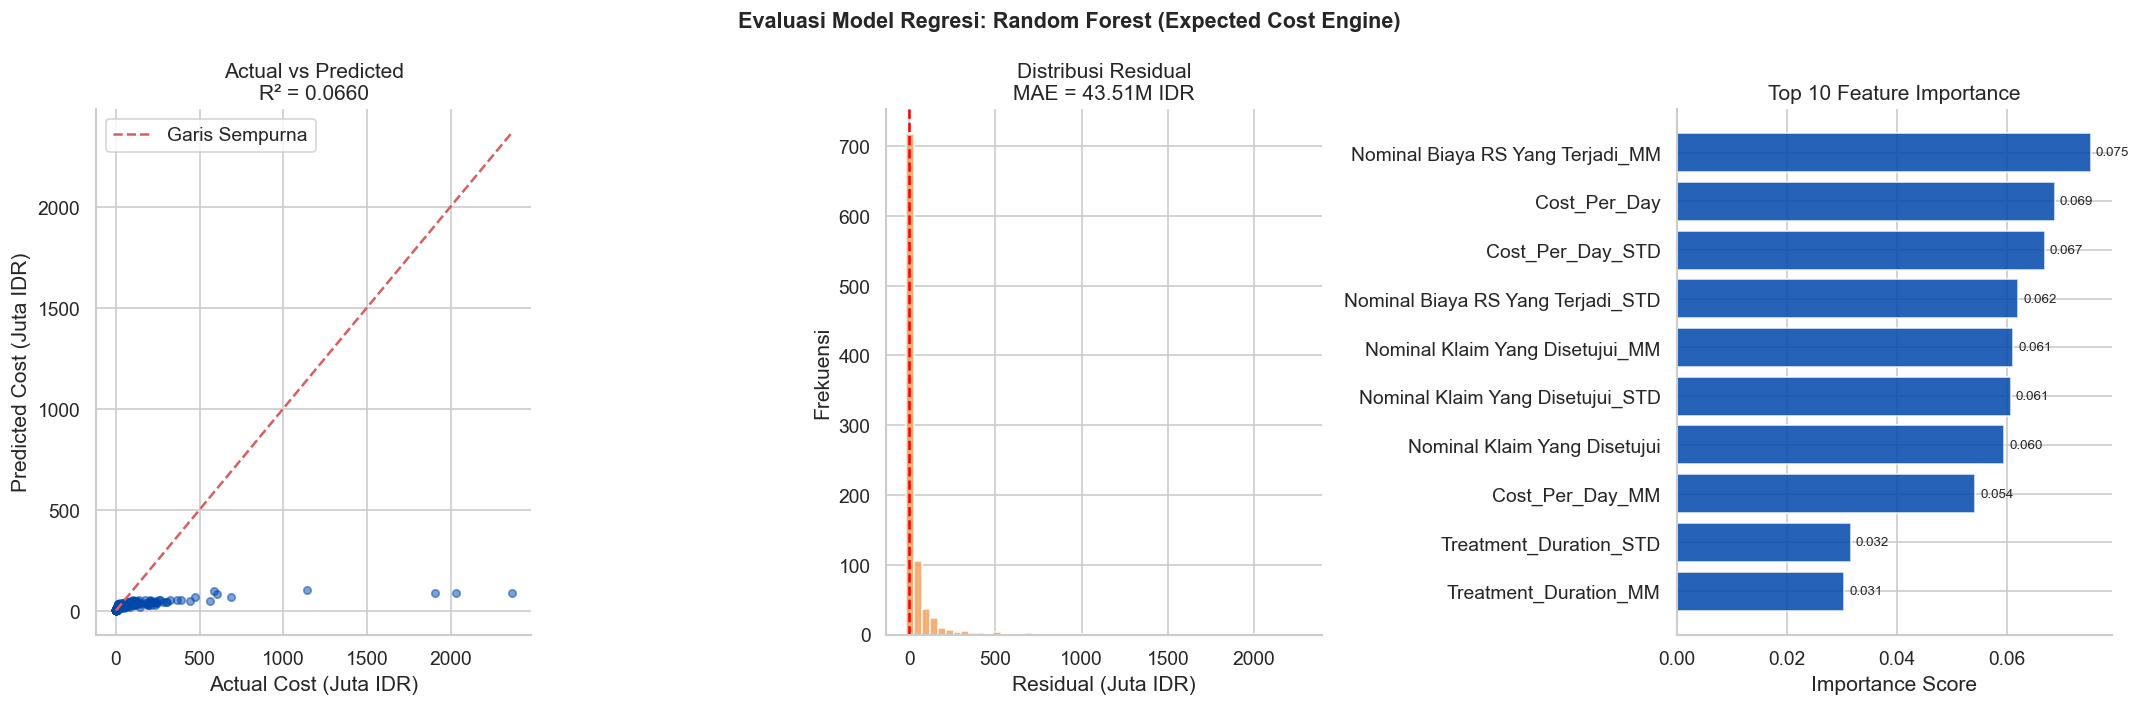


--- Tabel Perbandingan Model Regresi ---


,Model,MAE (IDR),RMSE (IDR),R² Score
0,Random Forest,"43,507,862","175,687,704",0.0660


In [15]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
# ================================================================
# SEL 3: REGRESSION MODEL - EXPECTED COST ENGINE
# ================================================================
X_reg = df[REGRESSION_FEATURES].copy()
X_reg = pd.get_dummies(X_reg, drop_first=True)  # <-- TAMBAHKAN INI
y_reg = np.log1p(df[TARGET_REG])

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f"Training set : {len(X_train):,} sampel")
print(f"Testing set  : {len(X_test):,} sampel")
print(f"Fitur        : {len(REGRESSION_FEATURES)}")

X_reg = pd.get_dummies(X_reg, drop_first=True)

# ----------------------------------------------------------------
# MODEL 1: RANDOM FOREST REGRESSOR
# Random Forest dipilih karena robust terhadap outlier, tidak
# memerlukan normalisasi tambahan, dan memberikan feature importance
# yang interpretatif untuk kebutuhan bisnis asuransi.
# ----------------------------------------------------------------

print("\nMembangun Random Forest Regressor...")
rf_model = RandomForestRegressor(
    n_estimators=N_ESTIMATORS_RF,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf_log  = rf_model.predict(X_test)
y_pred_rf      = np.expm1(y_pred_rf_log)
y_test_actual  = np.expm1(y_test)

mae_rf  = mean_absolute_error(y_test_actual, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_actual, y_pred_rf))
r2_rf   = r2_score(y_test_actual, y_pred_rf)

print(f"\n[Random Forest] MAE  : IDR {mae_rf:,.0f}")
print(f"[Random Forest] RMSE : IDR {rmse_rf:,.0f}")
print(f"[Random Forest] R²   : {r2_rf:.4f}")

# ----------------------------------------------------------------
# MODEL 2: XGBOOST REGRESSOR (Jika Tersedia)
# XGBoost memberikan akurasi lebih tinggi melalui boosting gradient,
# namun lebih kompleks dan memerlukan tuning hyperparameter.
# ----------------------------------------------------------------

if XGB_AVAILABLE:
    print("\nMembangun XGBoost Regressor...")
    xgb_model = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0
    )
    xgb_model.fit(X_train, y_train,
                  eval_set=[(X_test, y_test)],
                  verbose=False)

    y_pred_xgb_log = xgb_model.predict(X_test)
    y_pred_xgb     = np.expm1(y_pred_xgb_log)

    mae_xgb  = mean_absolute_error(y_test_actual, y_pred_xgb)
    rmse_xgb = np.sqrt(mean_squared_error(y_test_actual, y_pred_xgb))
    r2_xgb   = r2_score(y_test_actual, y_pred_xgb)

    print(f"[XGBoost]       MAE  : IDR {mae_xgb:,.0f}")
    print(f"[XGBoost]       RMSE : IDR {rmse_xgb:,.0f}")
    print(f"[XGBoost]       R²   : {r2_xgb:.4f}")

    # Pilih model terbaik berdasarkan RMSE
    BEST_MODEL      = xgb_model if rmse_xgb < rmse_rf else rf_model
    BEST_MODEL_NAME = "XGBoost" if rmse_xgb < rmse_rf else "Random Forest"
    BEST_PREDS_TEST = y_pred_xgb if rmse_xgb < rmse_rf else y_pred_rf
else:
    BEST_MODEL      = rf_model
    BEST_MODEL_NAME = "Random Forest"
    BEST_PREDS_TEST = y_pred_rf

print(f"\n[KEPUTUSAN] Model terpilih sebagai Expected Cost Engine: {BEST_MODEL_NAME}")

# ----------------------------------------------------------------
# PREDIKSI PADA SELURUH DATASET (UNTUK MENGHITUNG RISK DEVIATION)
# ----------------------------------------------------------------

y_expected_log = BEST_MODEL.predict(X_reg)
df['Expected_Cost'] = np.expm1(y_expected_log)
df['Risk_Deviation'] = df[TARGET_REG] - df['Expected_Cost']
df['Risk_Deviation_Pct'] = (
    df['Risk_Deviation'] / df['Expected_Cost'].replace(0, np.nan)
).fillna(0) * 100

print("\nKolom baru ditambahkan ke dataset:")
print(f"  Expected_Cost     : Biaya RS yang diprediksi model")
print(f"  Risk_Deviation     : Selisih (Actual - Expected) dalam IDR")
print(f"  Risk_Deviation_Pct : Persentase deviasi terhadap ekspektasi")

# ----------------------------------------------------------------
# VISUALISASI EVALUASI MODEL
# ----------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f'Evaluasi Model Regresi: {BEST_MODEL_NAME} (Expected Cost Engine)',
             fontweight='bold', fontsize=13)

# Panel 1: Actual vs Predicted Scatter
ax = axes[0]
sample_idx = np.random.choice(len(y_test_actual), min(500, len(y_test_actual)), replace=False)
ax.scatter(y_test_actual.iloc[sample_idx]/1e6, BEST_PREDS_TEST[sample_idx]/1e6,
           alpha=0.5, color=COLOR_PALETTE['primary'], s=20)
max_val = max(y_test_actual.max(), BEST_PREDS_TEST.max()) / 1e6
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Garis Sempurna')
ax.set_xlabel('Actual Cost (Juta IDR)')
ax.set_ylabel('Predicted Cost (Juta IDR)')
ax.set_title(f'Actual vs Predicted\nR² = {r2_score(y_test_actual, BEST_PREDS_TEST):.4f}')
ax.legend()

# Panel 2: Residual Distribution
residuals = y_test_actual - BEST_PREDS_TEST
ax2 = axes[1]
ax2.hist(residuals/1e6, bins=50, color=COLOR_PALETTE['warning'],
         edgecolor='white', alpha=0.85)
ax2.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Residual (Juta IDR)')
ax2.set_ylabel('Frekuensi')
ax2.set_title(f'Distribusi Residual\nMAE = {mae_rf/1e6:.2f}M IDR')

# Panel 3: Feature Importance
ax3 = axes[2]
if BEST_MODEL_NAME == "Random Forest":
    importance = rf_model.feature_importances_
else:
    importance = xgb_model.feature_importances_

feat_imp = pd.DataFrame({
    'Fitur': X_reg.columns,
    'Importance': importance
}).sort_values('Importance', ascending=True).tail(10)

bars = ax3.barh(feat_imp['Fitur'], feat_imp['Importance'],
                color=COLOR_PALETTE['primary'], edgecolor='white', alpha=0.85)
ax3.set_title('Top 10 Feature Importance')
ax3.set_xlabel('Importance Score')
ax3.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)

plt.tight_layout()
plt.show()

# Tabel perbandingan model
print("\n--- Tabel Perbandingan Model Regresi ---")
comparison_data = {
    'Model': ['Random Forest'],
    'MAE (IDR)': [f'{mae_rf:,.0f}'],
    'RMSE (IDR)': [f'{rmse_rf:,.0f}'],
    'R² Score': [f'{r2_rf:.4f}']
}
if XGB_AVAILABLE:
    comparison_data['Model'].append('XGBoost')
    comparison_data['MAE (IDR)'].append(f'{mae_xgb:,.0f}')
    comparison_data['RMSE (IDR)'].append(f'{rmse_xgb:,.0f}')
    comparison_data['R² Score'].append(f'{r2_xgb:.4f}')
display(pd.DataFrame(comparison_data))

---
## Sel 4: Isolation Forest - Anomaly Detection Engine

**Tujuan:** Mendeteksi klaim yang secara statistik menyimpang dari pola normal
menggunakan Isolation Forest. Algoritma ini bekerja dengan prinsip bahwa titik
data anomali lebih mudah untuk "diisolasi" karena terletak di region yang jarang
dalam ruang fitur.

**Logika Integrasi:** Input utama Isolation Forest adalah `Risk_Deviation`
(selisih antara biaya aktual dan expected cost), dikombinasikan dengan fitur
perilaku klaim lainnya. Ini memastikan anomali yang terdeteksi adalah anomali
yang relevan secara bisnis, bukan sekadar nilai ekstrem statistik.

Melatih Isolation Forest...

Hasil Isolation Forest:
  Klaim Normal  : 4,164 (90.0%)
  Klaim Anomali : 463 (10.0%)
  Rata-rata Anomaly Score (Anomali) : 0.5813
  Rata-rata Anomaly Score (Normal)  : 0.1382


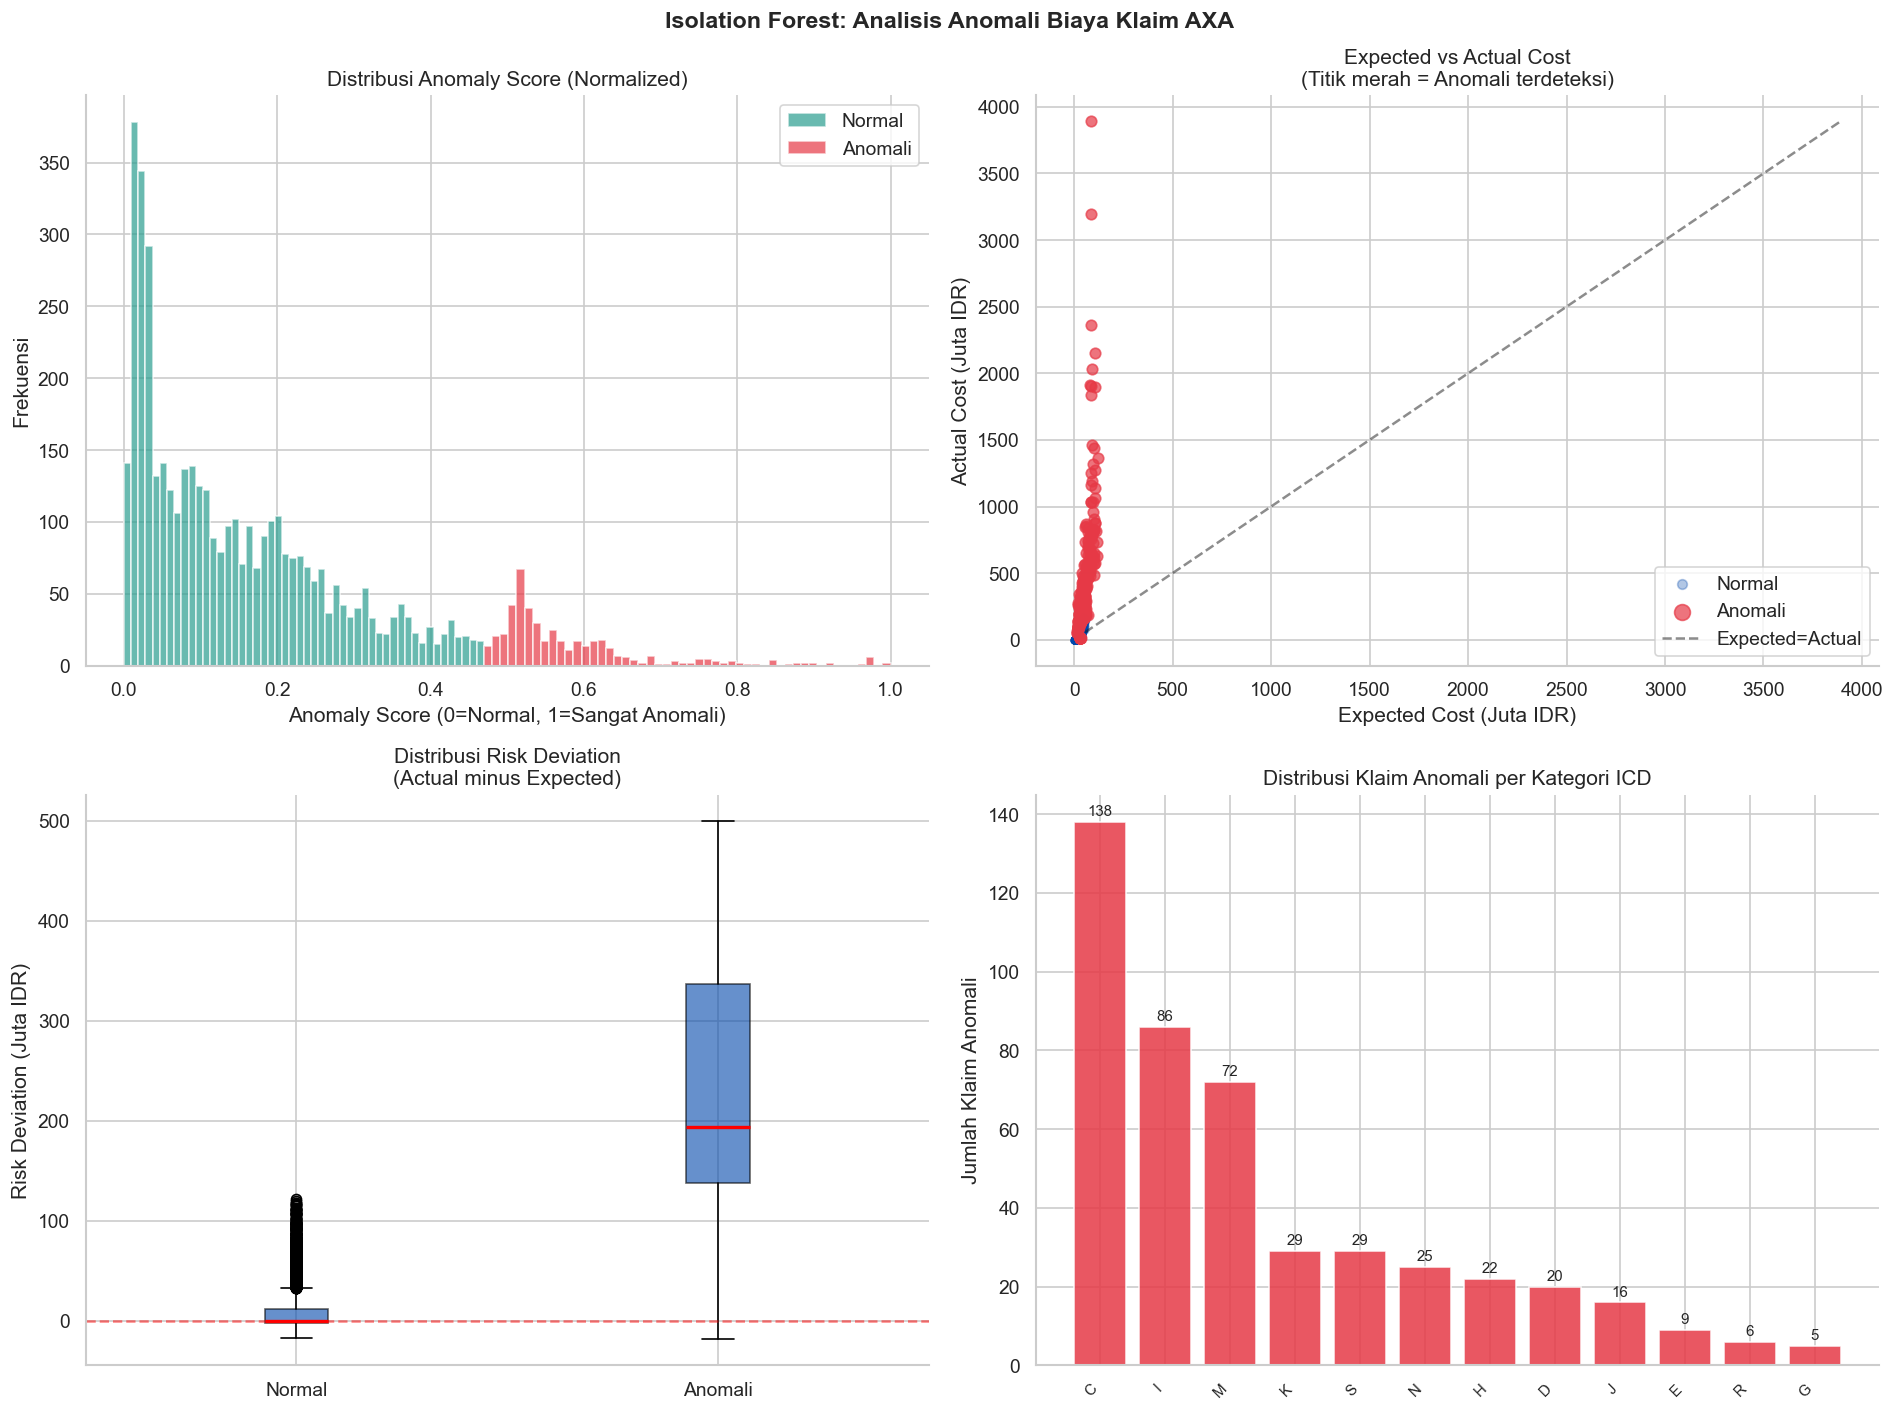


--- Top 10 Klaim dengan Anomaly Score Tertinggi ---


,Claim ID,Nomor Polis,ICD_Category,Expected_Cost,Nominal Biaya RS Yang Terjadi,Risk_Deviation,Anomaly_Score_Norm,Is_Overseas
905,C-1162-M,POL-0830,E,IDR 84.83M,IDR 3892.81M,IDR 3807.98M,1.0000,1
324,C-0449-M,POL-2551,I,IDR 88.10M,IDR 3192.70M,IDR 3104.60M,0.9938,1
1504,C-1919-M,POL-3316,J,IDR 86.54M,IDR 2364.32M,IDR 2277.77M,0.9782,1
252,C-0353-M,POL-3622,C,IDR 105.97M,IDR 2152.37M,IDR 2046.40M,0.9770,1
367,C-0501-M,POL-2535,I,IDR 88.76M,IDR 2035.14M,IDR 1946.38M,0.9739,1
964,C-1231-M,POL-1240,E,IDR 87.65M,IDR 1905.64M,IDR 1817.99M,0.9702,1
2104,C-2713-M,POL-0587,D,IDR 82.23M,IDR 1912.35M,IDR 1830.11M,0.9702,1
2584,C-3367-M,POL-1988,I,IDR 107.18M,IDR 1898.03M,IDR 1790.86M,0.9684,1
1483,C-1898-M,POL-3716,S,IDR 88.25M,IDR 1835.87M,IDR 1747.62M,0.9622,1
904,C-1161-M,POL-0830,C,IDR 88.97M,IDR 1465.63M,IDR 1376.66M,0.9218,0


In [17]:
# ================================================================
# SEL 4: ISOLATION FOREST - ANOMALY DETECTION ENGINE
# ================================================================

# Bangun matriks fitur khusus untuk Isolation Forest
# Sertakan Risk_Deviation sebagai fitur kunci
IF_EXTENDED_FEATURES = ANOMALY_FEATURES.copy()

# Tambahkan fitur Risk Deviation yang baru dihitung
scaler_dev = MinMaxScaler()
df['Risk_Deviation_Scaled'] = scaler_dev.fit_transform(
    df[['Risk_Deviation']]
)
df['Risk_Dev_Pct_Scaled'] = scaler_dev.fit_transform(
    df[['Risk_Deviation_Pct']].clip(lower=-500, upper=500)
)
IF_EXTENDED_FEATURES += ['Risk_Deviation_Scaled', 'Risk_Dev_Pct_Scaled']

X_anomaly = df[IF_EXTENDED_FEATURES].fillna(0)

# ----------------------------------------------------------------
# ISOLATION FOREST
# Contamination = 0.10 berarti kita mengekspektasikan 10% klaim
# adalah anomali. Parameter ini dapat dikalibrasi ulang berdasarkan
# audit historis fraud AXA.
# ----------------------------------------------------------------

print("Melatih Isolation Forest...")
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=IF_CONTAMINATION,
    max_samples='auto',
    max_features=1.0,
    bootstrap=False,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso_forest.fit(X_anomaly)

# Anomaly Score: nilai lebih negatif = lebih anomali
# Label: -1 = anomali, 1 = normal
df['IF_Score']    = iso_forest.score_samples(X_anomaly)
df['IF_Label']    = iso_forest.predict(X_anomaly)
df['Is_Anomaly']  = (df['IF_Label'] == -1).astype(int)

# Normalisasi skor ke rentang [0, 1] untuk kemudahan interpretasi
# Skor 1 = paling anomali, 0 = paling normal
df['Anomaly_Score_Norm'] = (
    (df['IF_Score'] - df['IF_Score'].max()) /
    (df['IF_Score'].min() - df['IF_Score'].max())
).clip(0, 1)

anomaly_count = df['Is_Anomaly'].sum()
normal_count  = len(df) - anomaly_count

print(f"\nHasil Isolation Forest:")
print(f"  Klaim Normal  : {normal_count:,} ({normal_count/len(df)*100:.1f}%)")
print(f"  Klaim Anomali : {anomaly_count:,} ({anomaly_count/len(df)*100:.1f}%)")
print(f"  Rata-rata Anomaly Score (Anomali) : {df[df['Is_Anomaly']==1]['Anomaly_Score_Norm'].mean():.4f}")
print(f"  Rata-rata Anomaly Score (Normal)  : {df[df['Is_Anomaly']==0]['Anomaly_Score_Norm'].mean():.4f}")

# ----------------------------------------------------------------
# VISUALISASI HASIL ISOLATION FOREST
# ----------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Isolation Forest: Analisis Anomali Biaya Klaim AXA',
             fontweight='bold', fontsize=14)

# Panel 1: Distribusi Anomaly Score
ax = axes[0][0]
ax.hist(df[df['Is_Anomaly']==0]['Anomaly_Score_Norm'], bins=50,
        color=COLOR_PALETTE['success'], alpha=0.7, label='Normal')
ax.hist(df[df['Is_Anomaly']==1]['Anomaly_Score_Norm'], bins=50,
        color=COLOR_PALETTE['danger'], alpha=0.7, label='Anomali')
ax.set_title('Distribusi Anomaly Score (Normalized)')
ax.set_xlabel('Anomaly Score (0=Normal, 1=Sangat Anomali)')
ax.set_ylabel('Frekuensi')
ax.legend()

# Panel 2: Expected vs Actual Cost dengan Anomali
ax2 = axes[0][1]
normal_mask  = df['Is_Anomaly'] == 0
anomaly_mask = df['Is_Anomaly'] == 1
ax2.scatter(df[normal_mask]['Expected_Cost']/1e6,
            df[normal_mask][TARGET_REG]/1e6,
            alpha=0.3, c=COLOR_PALETTE['primary'], s=15, label='Normal')
ax2.scatter(df[anomaly_mask]['Expected_Cost']/1e6,
            df[anomaly_mask][TARGET_REG]/1e6,
            alpha=0.7, c=COLOR_PALETTE['danger'], s=40, label='Anomali', zorder=5)
max_v = df[[TARGET_REG, 'Expected_Cost']].max().max() / 1e6
ax2.plot([0, max_v], [0, max_v], 'k--', linewidth=1.5, alpha=0.5, label='Expected=Actual')
ax2.set_xlabel('Expected Cost (Juta IDR)')
ax2.set_ylabel('Actual Cost (Juta IDR)')
ax2.set_title('Expected vs Actual Cost\n(Titik merah = Anomali terdeteksi)')
ax2.legend(markerscale=1.5)

# Panel 3: Risk Deviation Distribution per Label
ax3 = axes[1][0]
dev_normal  = df[normal_mask]['Risk_Deviation']/1e6
dev_anomali = df[anomaly_mask]['Risk_Deviation']/1e6
ax3.boxplot([dev_normal.clip(-500, 500), dev_anomali.clip(-500, 500)],
            labels=['Normal', 'Anomali'],
            patch_artist=True,
            boxprops=dict(facecolor=COLOR_PALETTE['primary'], alpha=0.6),
            medianprops=dict(color='red', linewidth=2))
ax3.set_title('Distribusi Risk Deviation\n(Actual minus Expected)')
ax3.set_ylabel('Risk Deviation (Juta IDR)')
ax3.axhline(0, color='red', linestyle='--', alpha=0.5)

# Panel 4: Top Anomali berdasarkan ICD Category
ax4 = axes[1][1]
icd_anomaly = df[anomaly_mask].groupby('ICD_Category').size().sort_values(ascending=False).head(12)
bars = ax4.bar(range(len(icd_anomaly)), icd_anomaly.values,
               color=COLOR_PALETTE['danger'], edgecolor='white', alpha=0.85)
ax4.set_xticks(range(len(icd_anomaly)))
ax4.set_xticklabels(icd_anomaly.index, rotation=45, ha='right', fontsize=9)
ax4.set_title('Distribusi Klaim Anomali per Kategori ICD')
ax4.set_ylabel('Jumlah Klaim Anomali')
ax4.bar_label(bars, padding=2, fontsize=9)

plt.tight_layout()
plt.show()

print("\n--- Top 10 Klaim dengan Anomaly Score Tertinggi ---")
top_anomaly = df.nlargest(10, 'Anomaly_Score_Norm')[[
    'Claim ID', 'Nomor Polis', 'ICD_Category',
    'Expected_Cost', TARGET_REG, 'Risk_Deviation',
    'Anomaly_Score_Norm', 'Is_Overseas'
]].copy()
top_anomaly['Expected_Cost'] = top_anomaly['Expected_Cost'].apply(lambda x: f"IDR {x/1e6:.2f}M")
top_anomaly[TARGET_REG]     = top_anomaly[TARGET_REG].apply(lambda x: f"IDR {x/1e6:.2f}M")
top_anomaly['Risk_Deviation'] = top_anomaly['Risk_Deviation'].apply(lambda x: f"IDR {x/1e6:.2f}M")
display(top_anomaly)

---
## Sel 5: K-Means Clustering - Risk Segmentation Engine

**Tujuan:** Mengelompokkan nasabah ke dalam segmen risiko yang homogen untuk
mengidentifikasi *root cause* kenaikan biaya. Clustering memungkinkan AXA
memahami *pola perilaku* di balik angka, bukan hanya menemukan outlier individual.

**Metode Penentuan K:** Elbow Method dan Silhouette Score digunakan bersama
untuk memilih jumlah cluster yang optimal secara objektif.

In [20]:
print(ANOMALY_FEATURES)


[]


Menghitung Elbow dan Silhouette untuk K=2 hingga K=8...
  K=2: Inertia=146,781,381,780,205,371,392, Silhouette=0.9025
  K=3: Inertia=83,377,947,663,744,106,496, Silhouette=0.8453
  K=4: Inertia=53,555,726,860,969,476,096, Silhouette=0.7636
  K=5: Inertia=40,938,711,678,038,540,288, Silhouette=0.7128
  K=6: Inertia=31,509,010,589,761,388,544, Silhouette=0.7017
  K=7: Inertia=26,162,628,192,930,689,024, Silhouette=0.6633
  K=8: Inertia=22,062,639,342,702,641,152, Silhouette=0.6480


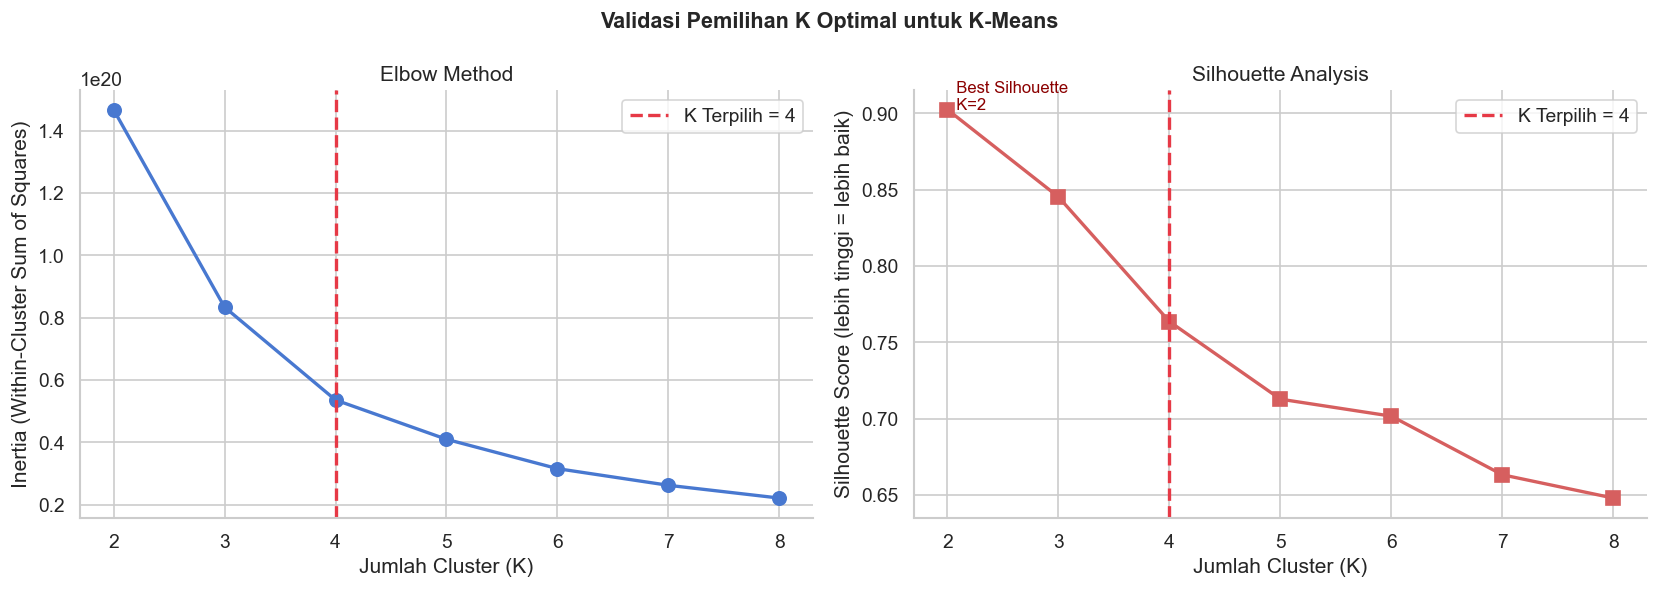


Melatih K-Means dengan K=4...
Silhouette Score Final (K=4): 0.7531

--- Profil Setiap Cluster ---


,N_Klaim,Avg_Actual_Cost,Avg_Expected_Cost,Avg_Risk_Deviation,Avg_Dev_Pct,Avg_Claim_Freq,Pct_Overseas,Pct_Anomaly,Avg_Patient_Age,Pct_Chronic
Cluster,,,,,,,,,,
0,4053,"23,002,648.7100","16,421,776.9100","6,580,871.8100",2.7400,30.7000,0.2800,0.0100,58.9700,8.4200
1,91,"694,404,832.9700","79,513,931.0300","614,890,901.9500",786.9500,7.4300,0.8600,1.0000,62.5200,7.8900
2,472,"205,237,429.0400","42,570,440.7500","162,666,988.2900",389.9000,10.9500,0.5900,0.7000,61.7100,7.1700
3,11,"2,190,293,011.4500","91,614,770.4600","2,098,678,240.9900","2,328.7200",5.4500,0.9100,1.0000,69.0300,6.0000



Label Cluster:
  Cluster 0: Cluster C: High-Frequency Utilizer
  Cluster 1: Cluster A: High-Risk Anomali
  Cluster 2: Cluster A: High-Risk Anomali
  Cluster 3: Cluster A: High-Risk Anomali


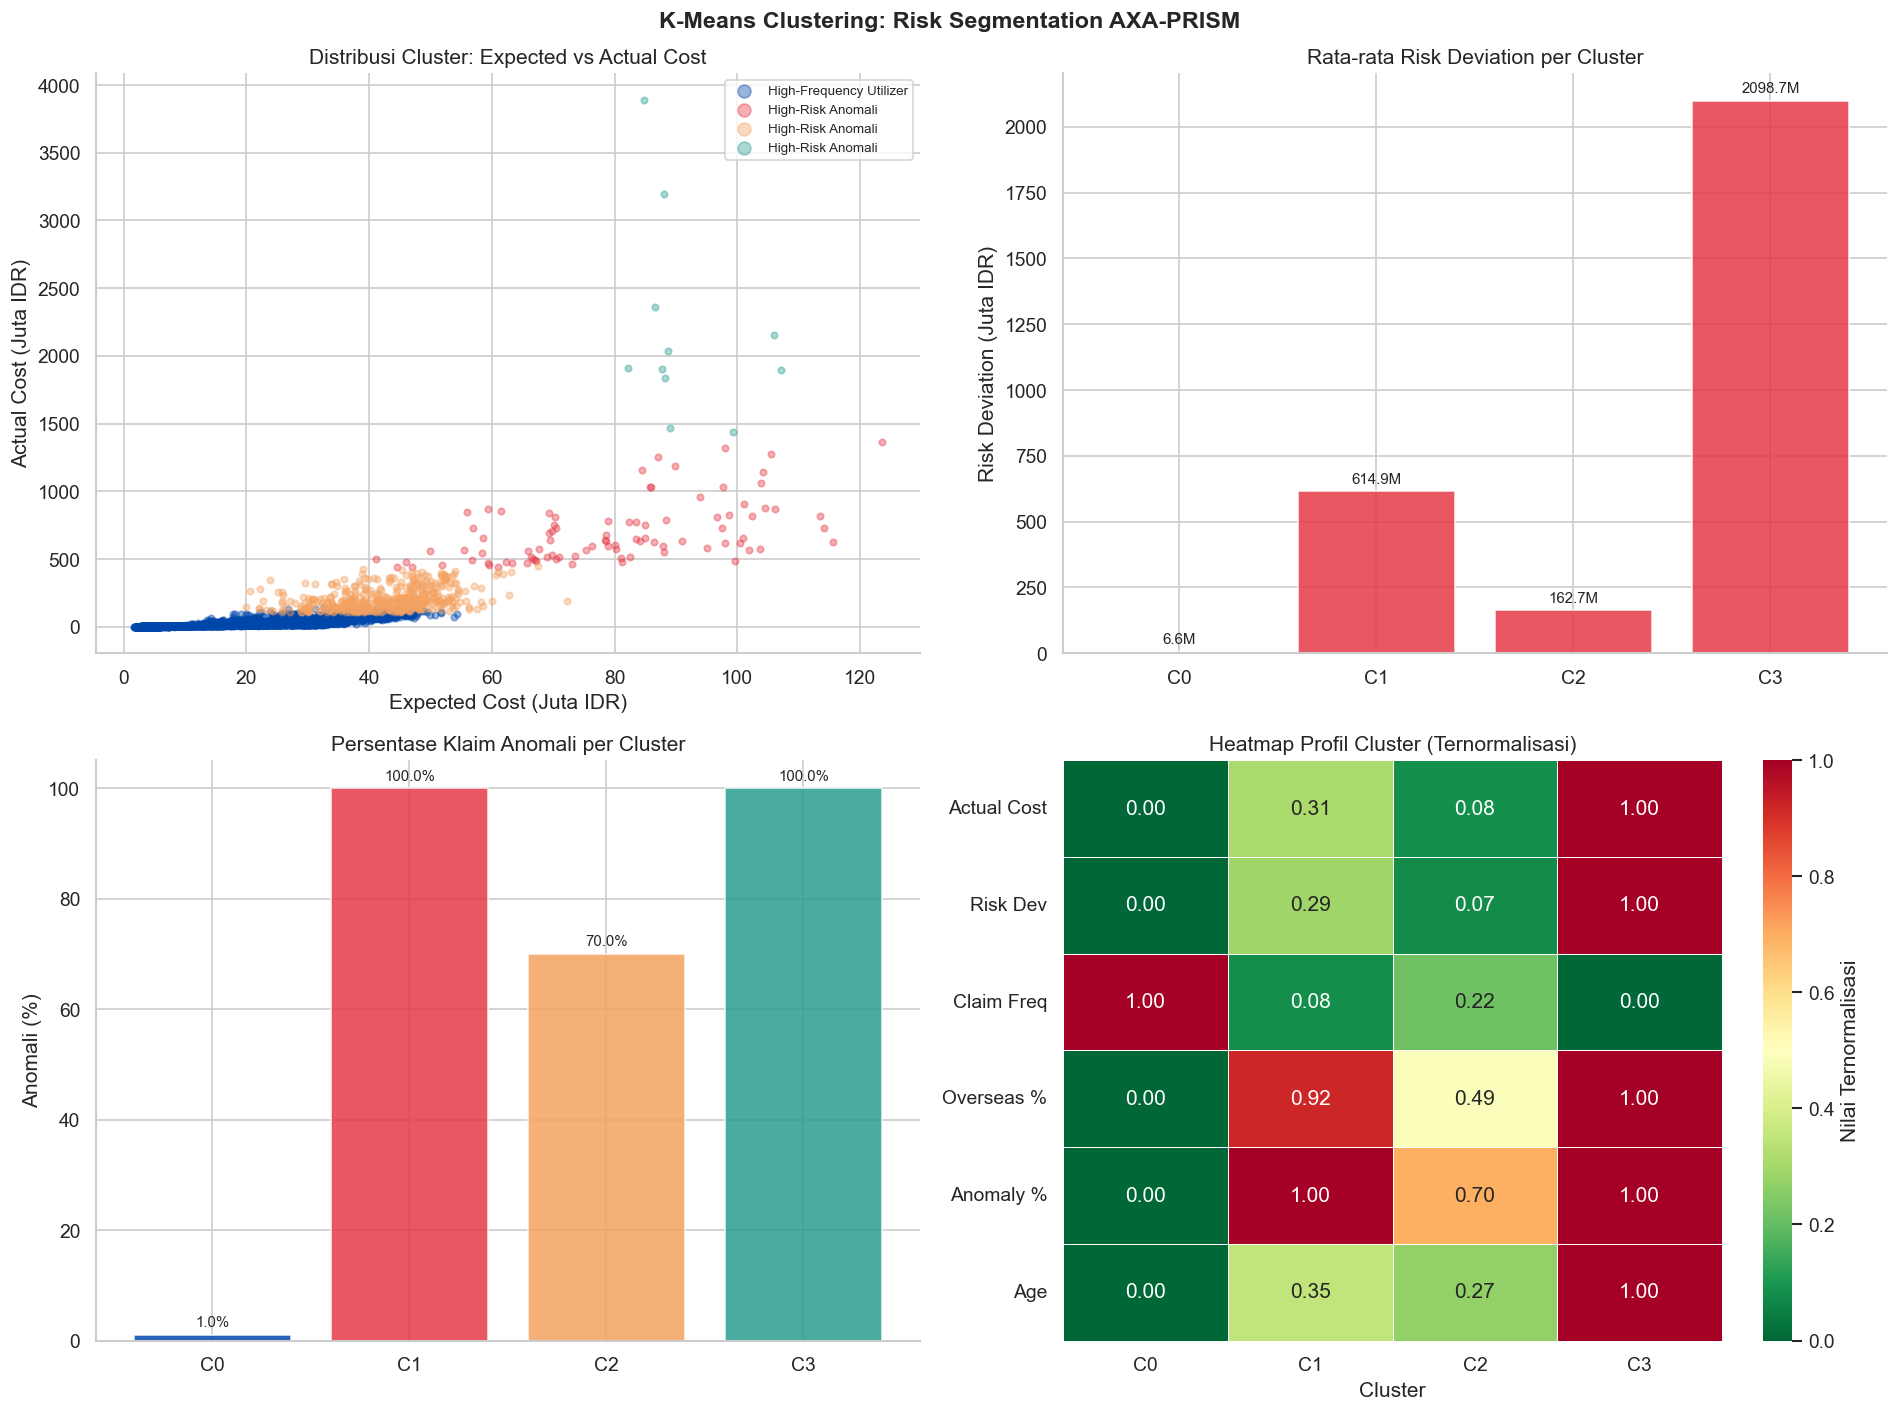

In [24]:
# ================================================================
# SEL 5: K-MEANS CLUSTERING - RISK SEGMENTATION ENGINE
# ================================================================

X_cluster = df.select_dtypes(include=np.number).fillna(0)

# ----------------------------------------------------------------
# LANGKAH 1: VALIDASI K OPTIMAL
# Gunakan Elbow Method dan Silhouette Score untuk memastikan
# pilihan K=4 adalah yang terbaik secara statistik
# ----------------------------------------------------------------

print("Menghitung Elbow dan Silhouette untuk K=2 hingga K=8...")
k_range       = range(2, 9)
inertia_vals  = []
silhouette_vals = []

for k in k_range:
    km_temp = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_temp = km_temp.fit_predict(X_cluster)
    inertia_vals.append(km_temp.inertia_)
    sil = silhouette_score(X_cluster, labels_temp, sample_size=min(2000, len(df)))
    silhouette_vals.append(sil)
    print(f"  K={k}: Inertia={km_temp.inertia_:,.0f}, Silhouette={sil:.4f}")

# Visualisasi Elbow dan Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Validasi Pemilihan K Optimal untuk K-Means', fontweight='bold', fontsize=13)

axes[0].plot(k_range, inertia_vals, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(N_CLUSTERS, color=COLOR_PALETTE['danger'], linestyle='--',
                linewidth=2, label=f'K Terpilih = {N_CLUSTERS}')
axes[0].set_xlabel('Jumlah Cluster (K)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].set_title('Elbow Method')
axes[0].legend()

axes[1].plot(k_range, silhouette_vals, 'rs-', linewidth=2, markersize=8)
axes[1].axvline(N_CLUSTERS, color=COLOR_PALETTE['danger'], linestyle='--',
                linewidth=2, label=f'K Terpilih = {N_CLUSTERS}')
best_k_idx = silhouette_vals.index(max(silhouette_vals))
axes[1].annotate(f'  Best Silhouette\n  K={list(k_range)[best_k_idx]}',
                 xy=(list(k_range)[best_k_idx], max(silhouette_vals)),
                 fontsize=10, color='darkred')
axes[1].set_xlabel('Jumlah Cluster (K)')
axes[1].set_ylabel('Silhouette Score (lebih tinggi = lebih baik)')
axes[1].set_title('Silhouette Analysis')
axes[1].legend()

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------
# LANGKAH 2: FIT K-MEANS FINAL
# ----------------------------------------------------------------

print(f"\nMelatih K-Means dengan K={N_CLUSTERS}...")
kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    init='k-means++',     # Inisialisasi cerdas untuk konvergensi cepat
    n_init=20,            # 20 inisialisasi berbeda, ambil yang terbaik
    max_iter=500,
    random_state=RANDOM_STATE
)
df['Cluster'] = kmeans.fit_predict(X_cluster)

final_silhouette = silhouette_score(X_cluster, df['Cluster'], sample_size=min(2000, len(df)))
print(f"Silhouette Score Final (K={N_CLUSTERS}): {final_silhouette:.4f}")

# ----------------------------------------------------------------
# LANGKAH 3: INTERPRETASI DAN LABELING CLUSTER
# Analisis karakteristik setiap cluster untuk memberikan label
# yang bermakna secara bisnis
# ----------------------------------------------------------------

cluster_profile = df.groupby('Cluster').agg(
    N_Klaim               = ('Claim ID', 'count'),
    Avg_Actual_Cost       = (TARGET_REG, 'mean'),
    Avg_Expected_Cost     = ('Expected_Cost', 'mean'),
    Avg_Risk_Deviation    = ('Risk_Deviation', 'mean'),
    Avg_Dev_Pct           = ('Risk_Deviation_Pct', 'mean'),
    Avg_Claim_Freq        = ('Claim_Frequency', 'mean'),
    Pct_Overseas          = ('Is_Overseas', 'mean'),
    Pct_Anomaly           = ('Is_Anomaly', 'mean'),
    Avg_Patient_Age       = ('Patient_Age', 'mean'),
    Pct_Chronic           = ('ICD_Category_Enc', 'mean'),
).round(2)

print("\n--- Profil Setiap Cluster ---")
display(cluster_profile)

# Labeling otomatis berdasarkan karakteristik dominan
def assign_cluster_label(row):
    if row['Avg_Risk_Deviation'] > 0 and row['Pct_Anomaly'] > 0.15:
        return 'Cluster A: High-Risk Anomali'
    elif row['Pct_Overseas'] > 0.5:
        return 'Cluster B: Overseas High-Cost'
    elif row['Avg_Claim_Freq'] > cluster_profile['Avg_Claim_Freq'].median():
        return 'Cluster C: High-Frequency Utilizer'
    else:
        return 'Cluster D: Standard Risk'

cluster_labels = {
    idx: assign_cluster_label(row)
    for idx, row in cluster_profile.iterrows()
}
df['Cluster_Label'] = df['Cluster'].map(cluster_labels)
print("\nLabel Cluster:")
for k, v in cluster_labels.items():
    print(f"  Cluster {k}: {v}")

# ----------------------------------------------------------------
# VISUALISASI CLUSTERING
# ----------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('K-Means Clustering: Risk Segmentation AXA-PRISM',
             fontweight='bold', fontsize=14)

colors = [COLOR_PALETTE['clusters'][i] for i in range(N_CLUSTERS)]

# Panel 1: Scatter - Expected Cost vs Actual Cost per Cluster
ax = axes[0][0]
for cl in range(N_CLUSTERS):
    mask = df['Cluster'] == cl
    ax.scatter(df[mask]['Expected_Cost']/1e6,
               df[mask][TARGET_REG]/1e6,
               alpha=0.4, s=15, c=colors[cl],
               label=cluster_labels[cl].split(':')[1].strip())
ax.set_xlabel('Expected Cost (Juta IDR)')
ax.set_ylabel('Actual Cost (Juta IDR)')
ax.set_title('Distribusi Cluster: Expected vs Actual Cost')
ax.legend(fontsize=8, markerscale=2)

# Panel 2: Bar - Rata-rata Risk Deviation per Cluster
ax2 = axes[0][1]
dev_vals = cluster_profile['Avg_Risk_Deviation'] / 1e6
bar_colors = [COLOR_PALETTE['danger'] if v > 0 else COLOR_PALETTE['success']
              for v in dev_vals]
bars = ax2.bar(
    [f'C{i}' for i in cluster_profile.index],
    dev_vals,
    color=bar_colors, edgecolor='white', alpha=0.85
)
ax2.axhline(0, color='black', linewidth=1)
ax2.set_title('Rata-rata Risk Deviation per Cluster')
ax2.set_ylabel('Risk Deviation (Juta IDR)')
ax2.bar_label(bars, fmt='%.1fM', padding=3, fontsize=9)

# Panel 3: Proporsi Anomali per Cluster
ax3 = axes[1][0]
pct_anom = cluster_profile['Pct_Anomaly'] * 100
bars3 = ax3.bar(
    [f'C{i}' for i in cluster_profile.index],
    pct_anom,
    color=colors[:N_CLUSTERS], edgecolor='white', alpha=0.85
)
ax3.set_title('Persentase Klaim Anomali per Cluster')
ax3.set_ylabel('Anomali (%)')
ax3.bar_label(bars3, fmt='%.1f%%', padding=3, fontsize=9)

# Panel 4: Heatmap profil cluster
ax4 = axes[1][1]
heatmap_data = cluster_profile[[
    'Avg_Actual_Cost', 'Avg_Risk_Deviation', 'Avg_Claim_Freq',
    'Pct_Overseas', 'Pct_Anomaly', 'Avg_Patient_Age'
]].copy()
heatmap_data.columns = ['Actual Cost', 'Risk Dev', 'Claim Freq',
                        'Overseas %', 'Anomaly %', 'Age']
# Normalisasi per kolom untuk heatmap
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min() + 1e-10)
heatmap_norm.index = [f'C{i}' for i in heatmap_norm.index]
sns.heatmap(heatmap_norm.T, annot=True, fmt='.2f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax4, cbar_kws={'label': 'Nilai Ternormalisasi'})
ax4.set_title('Heatmap Profil Cluster (Ternormalisasi)')
ax4.set_xlabel('Cluster')

plt.tight_layout()
plt.show()

---
## Sel 6: Expert System Models - Komparator Berbasis Pengetahuan

**Tujuan:** Mengimplementasikan empat model sistem pakar sebagai komparator terhadap
model AI. Setiap model merepresentasikan pendekatan pengambilan keputusan yang
berbeda secara epistemologis.

**Nilai Strategis Komparasi:**
Jika model AI dan sistem pakar SEPAKAT bahwa sebuah klaim adalah anomali,
tingkat kepercayaan terhadap keputusan tersebut meningkat secara signifikan.
Kesepakatan lintas metode ini membentuk dasar *Confidence Score* akhir AXA-PRISM.

In [25]:
# ================================================================
# SEL 6A: FORWARD CHAINING - Rule-Based Classification
# ================================================================
# Prinsip: Mulai dari FAKTA, terapkan aturan IF-THEN secara
# berantai hingga mencapai kesimpulan klasifikasi risiko.
# Aturan disusun berdasarkan domain knowledge underwriter AXA.
# ================================================================

class ForwardChainingEngine:
    """
    Mesin Forward Chaining untuk klasifikasi risiko klaim asuransi.
    Setiap aturan memiliki prioritas (weight) dan menghasilkan
    fakta baru yang bisa memicu aturan berikutnya.
    """

    def __init__(self):
        # Basis pengetahuan (Knowledge Base)
        # Format: (kondisi_lambda, fakta_baru, label_aturan, bobot_risiko)
        self.rules = [
            # Aturan Tier-1: Sinyal Paling Kuat
            (lambda r: r.get('Is_Overseas', 0) == 1 and
                       r.get('Cost_Gap_Ratio', 0) < -0.5,
             'EXTREME_COST_OVERSEAS', 'R01-Overseas+OverApproval', 4),

            (lambda r: r.get('Claim_Frequency', 0) > 15 and
                       r.get('ICD_Category_Enc', 0) == 1,
             'HIGH_FREQUENCY_CHRONIC', 'R02-HighFreqChronic', 3),

            (lambda r: r.get('New_Policy_Claim_Flag', 0) == 1 and
                       r.get('High_Value_Claim_Flag', 0) == 1,
             'EARLY_HIGH_CLAIM', 'R03-EarlyHighClaim', 4),

            # Aturan Tier-2: Sinyal Sedang
            (lambda r: r.get('Treatment_Duration', 0) > 14 and
                       r.get('Is_Inpatient', 0) == 1,
             'LONG_INPATIENT', 'R04-LongInpatient', 2),

            (lambda r: r.get('Lokasi_RS_Risk_Score', 0) >= 4.0,
             'HIGH_RISK_LOCATION', 'R05-HighRiskLocation', 2),

            (lambda r: r.get('Cost_Gap_Ratio', 0) < -0.3,
             'APPROVAL_EXCEEDS_BILL', 'R06-OverApproval', 3),

            (lambda r: r.get('Patient_Age', 0) > 60 and
                       r.get('Claim_Frequency', 0) > 8,
             'SENIOR_HIGH_FREQ', 'R07-SeniorHighFreq', 2),

            (lambda r: r.get('Is_Overseas', 0) == 1,
             'OVERSEAS_FLAG', 'R08-OverseasTreatment', 1),

            # Aturan Tier-3: Sinyal Lemah
            (lambda r: r.get('Days_To_Payment', 0) > 60,
             'PAYMENT_DELAY', 'R09-PaymentDelay', 1),

            (lambda r: r.get('Reimburse_Encoded', 0) == 1 and
                       r.get('Is_Overseas', 0) == 1,
             'REIMBURSE_OVERSEAS', 'R10-ReimburseOverseas', 1),
        ]

    def classify(self, record):
        """
        Jalankan mesin inferensi forward chaining pada satu record.
        Return: (risk_score, risk_tier, rules_fired)
        """
        facts = dict(record)
        rules_fired = []
        risk_score = 0

        # Iterasi aturan hingga tidak ada aturan baru yang aktif
        changed = True
        while changed:
            changed = False
            for condition, new_fact, rule_name, weight in self.rules:
                if new_fact not in facts and condition(facts):
                    facts[new_fact] = True
                    rules_fired.append(rule_name)
                    risk_score += weight
                    changed = True

        # Tentukan tier risiko berdasarkan total skor
        if risk_score >= 7:
            tier = 'CRITICAL'
        elif risk_score >= 4:
            tier = 'HIGH'
        elif risk_score >= 2:
            tier = 'MEDIUM'
        else:
            tier = 'LOW'

        return risk_score, tier, rules_fired


print("Menjalankan Forward Chaining pada seluruh dataset...")
fc_engine = ForwardChainingEngine()
fc_results = df.apply(
    lambda row: fc_engine.classify(row.to_dict()), axis=1
)
df['FC_Risk_Score'] = fc_results.apply(lambda x: x[0])
df['FC_Risk_Tier']  = fc_results.apply(lambda x: x[1])
df['FC_Rules_Fired'] = fc_results.apply(lambda x: ', '.join(x[2]) if x[2] else 'Tidak ada')

print("Forward Chaining selesai.")
print("\nDistribusi Risk Tier (Forward Chaining):")
print(df['FC_Risk_Tier'].value_counts().to_dict())

Menjalankan Forward Chaining pada seluruh dataset...
Forward Chaining selesai.

Distribusi Risk Tier (Forward Chaining):
{'LOW': 3894, 'MEDIUM': 727, 'CRITICAL': 5, 'HIGH': 1}


In [26]:
# ================================================================
# SEL 6B: BACKWARD CHAINING - Goal-Driven Audit Engine
# ================================================================
# Prinsip: Mulai dari TUJUAN (goal), cari bukti yang membuktikan
# atau membantah tujuan tersebut.
# Goal: "Apakah klaim ini layak masuk daftar AUDIT MEDIS?"
# ================================================================

class BackwardChainingEngine:
    """
    Mesin Backward Chaining untuk menentukan apakah sebuah klaim
    harus dimasukkan ke antrian audit medis.

    Goal: AUDIT_REQUIRED = True
    Sub-goals yang harus dibuktikan:
    1. Ada bukti potensi over-billing
    2. Ada bukti abnormalitas klinis
    3. Ada bukti pola utilisasi berlebihan
    """

    def prove_goal(self, goal, facts, depth=0, trace=None):
        """
        Metode rekursif untuk membuktikan goal dari fakta yang ada.
        depth: kedalaman rekursi (mencegah infinite loop)
        trace: jejak pembuktian untuk audit trail
        """
        if trace is None:
            trace = []

        if depth > 5:
            return False, trace

        # --- Basis fakta langsung ---
        if goal == 'AUDIT_REQUIRED':
            # Buktikan salah satu sub-goal
            for subgoal in ['OVERBILLING_EVIDENCE', 'CLINICAL_ABNORMALITY',
                            'EXCESS_UTILIZATION']:
                result, trace = self.prove_goal(subgoal, facts, depth+1, trace)
                if result:
                    trace.append(f"Goal '{goal}' TERBUKTI melalui '{subgoal}'")
                    return True, trace
            trace.append(f"Goal '{goal}' TIDAK TERBUKTI")
            return False, trace

        elif goal == 'OVERBILLING_EVIDENCE':
            if facts.get('Cost_Gap_Ratio', 0) < -0.25:
                trace.append("Bukti: Klaim disetujui > 25% di atas biaya RS")
                return True, trace
            if facts.get('High_Value_Claim_Flag', 0) == 1 and                facts.get('Is_Overseas', 0) == 1:
                trace.append("Bukti: Klaim bernilai tinggi di luar negeri")
                return True, trace
            return False, trace

        elif goal == 'CLINICAL_ABNORMALITY':
            if facts.get('Treatment_Duration', 0) == 0 and                facts.get('Is_Inpatient', 0) == 1:
                trace.append("Bukti: Rawat inap tanpa durasi tercatat")
                return True, trace
            if facts.get('ICD_Category_Enc', 0) == 1 and                facts.get('New_Policy_Claim_Flag', 0) == 1:
                trace.append("Bukti: Penyakit kronis diklaim pada polis baru")
                return True, trace
            return False, trace

        elif goal == 'EXCESS_UTILIZATION':
            if facts.get('Claim_Frequency', 0) > 12:
                trace.append(f"Bukti: Frekuensi klaim {facts.get('Claim_Frequency'):.0f}x (>12)")
                return True, trace
            if facts.get('Claim_Frequency', 0) > 8 and                facts.get('Is_Overseas', 0) == 1:
                trace.append("Bukti: Klaim luar negeri berulang (>8x)")
                return True, trace
            return False, trace

        return False, trace

    def evaluate(self, record):
        facts = dict(record)
        audit_required, audit_trace = self.prove_goal('AUDIT_REQUIRED', facts)
        return int(audit_required), ' | '.join(audit_trace[-3:]) if audit_trace else 'N/A'


print("Menjalankan Backward Chaining pada seluruh dataset...")
bc_engine = BackwardChainingEngine()
bc_results = df.apply(
    lambda row: bc_engine.evaluate(row.to_dict()), axis=1
)
df['BC_Audit_Required'] = bc_results.apply(lambda x: x[0])
df['BC_Audit_Reason']   = bc_results.apply(lambda x: x[1])

audit_count = df['BC_Audit_Required'].sum()
print(f"\nHasil Backward Chaining:")
print(f"  Klaim yang Perlu Diaudit  : {audit_count:,} ({audit_count/len(df)*100:.1f}%)")
print(f"  Klaim yang Lolos Verifikasi: {len(df)-audit_count:,} ({(len(df)-audit_count)/len(df)*100:.1f}%)")

Menjalankan Backward Chaining pada seluruh dataset...

Hasil Backward Chaining:
  Klaim yang Perlu Diaudit  : 1,556 (33.6%)
  Klaim yang Lolos Verifikasi: 3,071 (66.4%)


Melatih Naive Bayes Risk Assessor...

Hasil Teorema Bayes:
  Rata-rata P(High-Risk) seluruh klaim : 0.1041
  Klaim diklasifikasi High-Risk         : 1


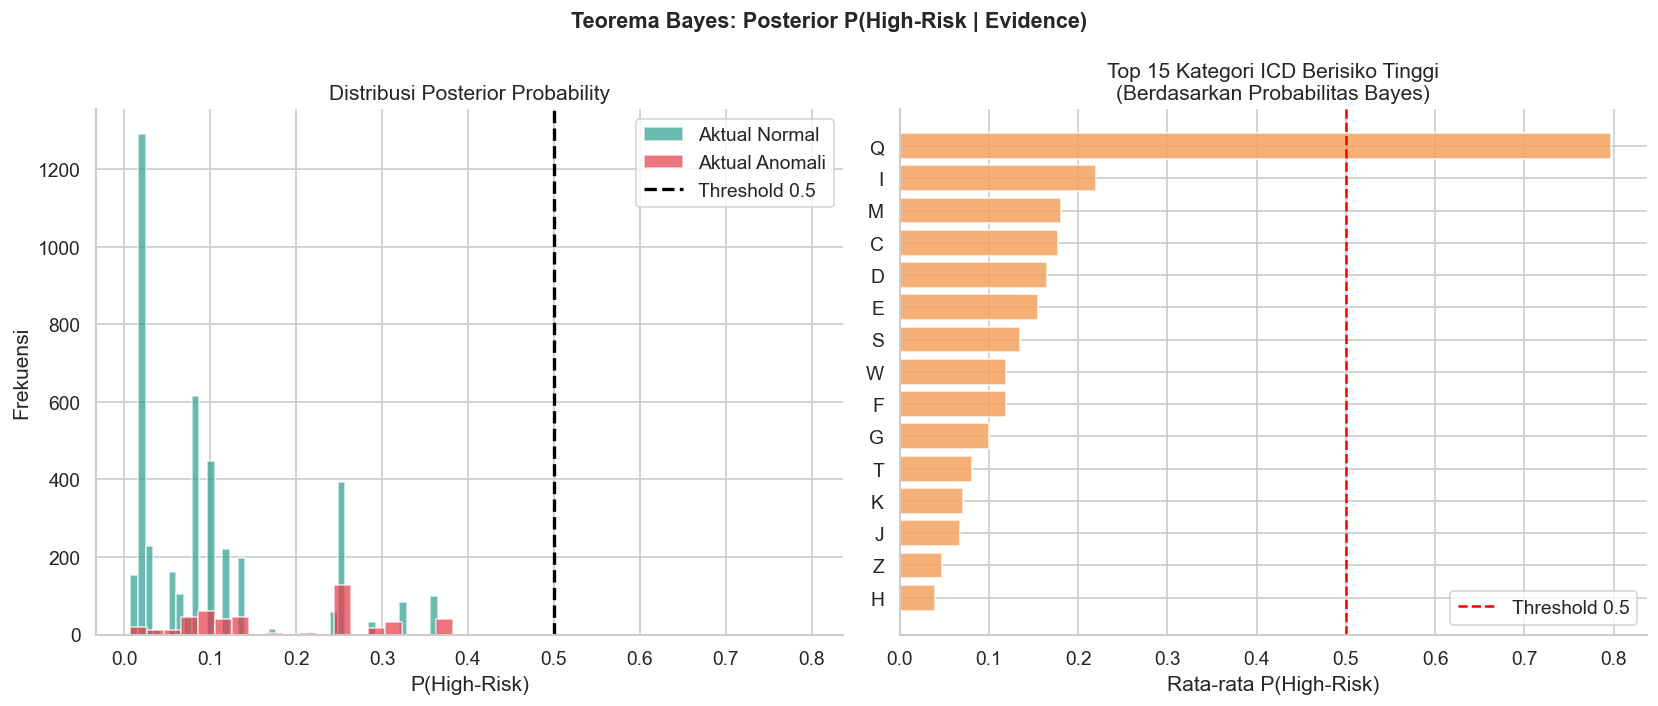

In [27]:
# ================================================================
# SEL 6C: TEOREMA BAYES - Probabilistic Risk Assessment
# ================================================================
# Prinsip: Hitung P(High-Risk | Evidence) menggunakan Teorema Bayes.
# P(H|E) = P(E|H) * P(H) / P(E)
#
# Hipotesis H: Nasabah adalah "High-Risk"
# Bukti E: Kombinasi Lokasi RS (overseas/domestic) dan Kategori ICD
# ================================================================

class NaiveBayesRiskAssessor:
    """
    Implementasi Naive Bayes untuk menghitung probabilitas
    posterior bahwa sebuah klaim termasuk kategori High-Risk.

    Menggunakan asumsi conditional independence antar fitur
    (Naive Bayes), sehingga perhitungan dapat dilakukan secara
    modular dan interpretatif.
    """

    def fit(self, df, target_col='Is_Anomaly'):
        """
        Estimasi parameter dari data pelatihan.
        Hitung P(H), P(Overseas|H), P(ICD_Cat|H) untuk setiap kelas.
        """
        self.classes = sorted(df[target_col].unique())
        n_total = len(df)

        # Prior probability P(H)
        self.prior = {}
        for cls in self.classes:
            self.prior[cls] = df[target_col].eq(cls).sum() / n_total

        # Likelihood P(Feature | Class) - dengan Laplace smoothing
        self.likelihood_overseas = {}
        self.likelihood_icd = {}

        for cls in self.classes:
            subset = df[df[target_col] == cls]
            n_cls  = len(subset)

            # P(Overseas=1 | Class)
            self.likelihood_overseas[cls] = {
                1: (subset['Is_Overseas'].sum() + 1) / (n_cls + 2),
                0: (n_cls - subset['Is_Overseas'].sum() + 1) / (n_cls + 2)
            }

            # P(ICD_Category | Class) - distribusi per kategori ICD
            icd_counts = subset['ICD_Category'].value_counts()
            n_icd_unique = df['ICD_Category'].nunique()
            self.likelihood_icd[cls] = {}
            for icd in df['ICD_Category'].unique():
                # Laplace smoothing: tambah 1 ke semua kategori
                self.likelihood_icd[cls][icd] = (
                    icd_counts.get(icd, 0) + 1
                ) / (n_cls + n_icd_unique)

        return self

    def predict_proba(self, overseas_val, icd_val):
        """
        Hitung posterior probability P(H|E) untuk setiap kelas.
        Return: dict {class: probability}
        """
        posteriors = {}
        for cls in self.classes:
            p_overseas = self.likelihood_overseas[cls].get(overseas_val, 1e-10)
            p_icd      = self.likelihood_icd[cls].get(icd_val, 1e-10)
            # Log-space untuk numerical stability
            log_posterior = (
                np.log(self.prior[cls]) +
                np.log(p_overseas) +
                np.log(p_icd)
            )
            posteriors[cls] = log_posterior

        # Softmax normalisasi untuk mendapatkan probabilitas valid
        max_log = max(posteriors.values())
        exp_vals = {cls: np.exp(v - max_log) for cls, v in posteriors.items()}
        total    = sum(exp_vals.values())
        return {cls: v / total for cls, v in exp_vals.items()}


print("Melatih Naive Bayes Risk Assessor...")
nb_assessor = NaiveBayesRiskAssessor()
nb_assessor.fit(df, target_col='Is_Anomaly')

# Prediksi probabilitas untuk setiap klaim
nb_proba = df.apply(
    lambda row: nb_assessor.predict_proba(
        row['Is_Overseas'],
        row['ICD_Category']
    ), axis=1
)
df['NB_P_HighRisk'] = nb_proba.apply(lambda x: x.get(1, 0.0))
df['NB_P_Normal']   = nb_proba.apply(lambda x: x.get(0, 1.0))
df['NB_Class']      = (df['NB_P_HighRisk'] >= 0.5).astype(int)

print("\nHasil Teorema Bayes:")
print(f"  Rata-rata P(High-Risk) seluruh klaim : {df['NB_P_HighRisk'].mean():.4f}")
print(f"  Klaim diklasifikasi High-Risk         : {df['NB_Class'].sum():,}")

# Visualisasi posterior probability per kombinasi ICD-Overseas
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Teorema Bayes: Posterior P(High-Risk | Evidence)',
             fontweight='bold', fontsize=13)

# Panel 1: Distribusi P(High-Risk)
axes[0].hist(df[df['Is_Anomaly']==0]['NB_P_HighRisk'], bins=40,
             color=COLOR_PALETTE['success'], alpha=0.7, label='Aktual Normal')
axes[0].hist(df[df['Is_Anomaly']==1]['NB_P_HighRisk'], bins=40,
             color=COLOR_PALETTE['danger'], alpha=0.7, label='Aktual Anomali')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Threshold 0.5')
axes[0].set_xlabel('P(High-Risk)')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Distribusi Posterior Probability')
axes[0].legend()

# Panel 2: P(High-Risk) per ICD Category
icd_risk_prob = df.groupby('ICD_Category')['NB_P_HighRisk'].mean().sort_values(ascending=False).head(15)
axes[1].barh(icd_risk_prob.index[::-1], icd_risk_prob.values[::-1],
             color=COLOR_PALETTE['warning'], edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Rata-rata P(High-Risk)')
axes[1].set_title('Top 15 Kategori ICD Berisiko Tinggi\n(Berdasarkan Probabilitas Bayes)')
axes[1].axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='Threshold 0.5')
axes[1].legend()

plt.tight_layout()
plt.show()

Menghitung Certainty Factors untuk seluruh dataset...

Distribusi Certainty Factor Label:
{'NORMAL': 1981, 'MENCURIGAKAN': 1349, 'PERLU PERHATIAN': 950, 'SANGAT MENCURIGAKAN': 347}

Rata-rata CF Score: 0.1447
CF Score tertinggi: 0.9775


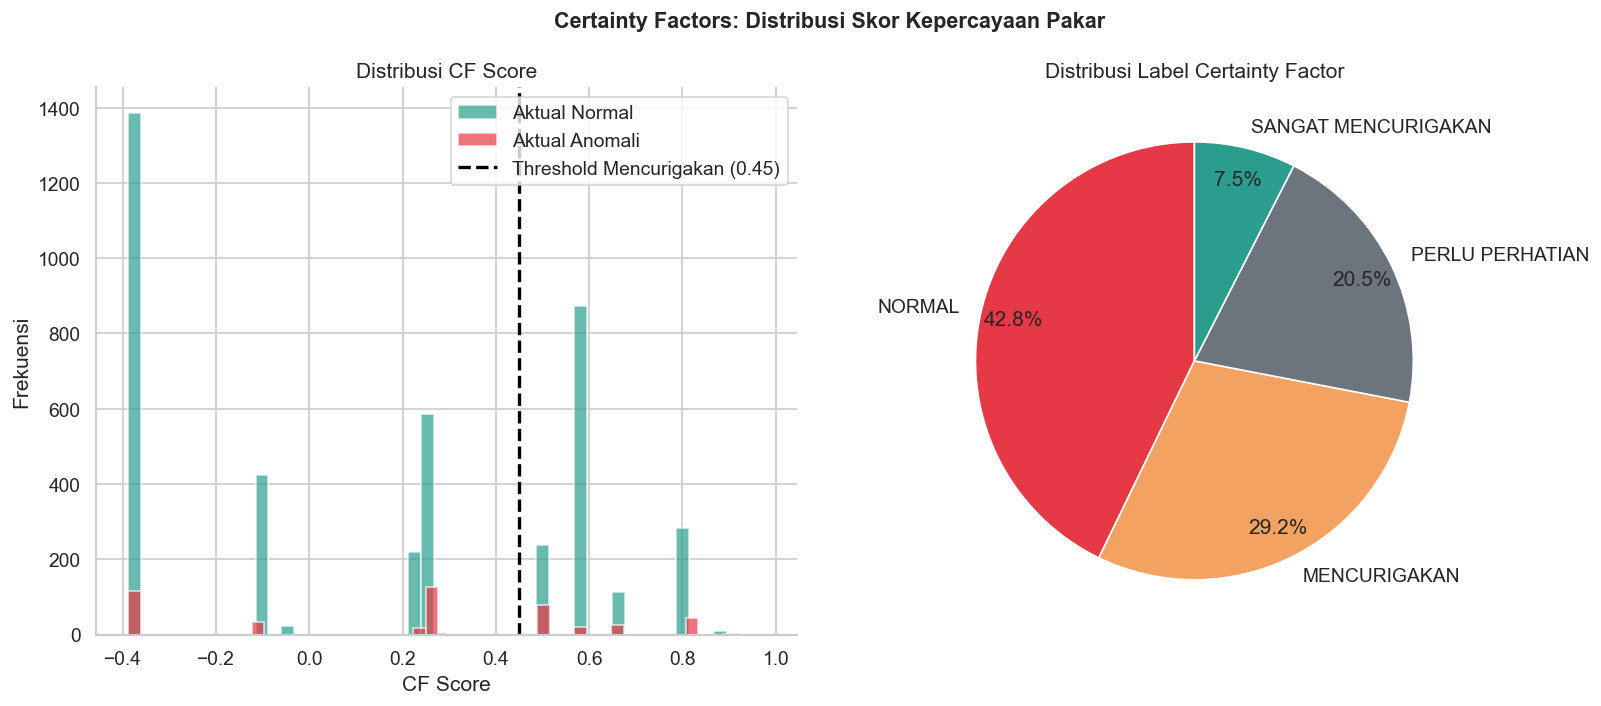

In [28]:
# ================================================================
# SEL 6D: CERTAINTY FACTORS (CF) - Uncertainty Handling Engine
# ================================================================
# Prinsip: CF mengukur tingkat kepercayaan pakar terhadap sebuah
# hipotesis. Nilai CF berkisar dari -1 (pasti salah) hingga +1
# (pasti benar). CF = 0 berarti tidak ada informasi.
#
# Rumus Kombinasi:
# CF(H, E1&E2) = CF(H,E1) + CF(H,E2) * (1 - CF(H,E1))  [keduanya positif]
# CF(H, E1&E2) = CF(H,E1) + CF(H,E2) * (1 + CF(H,E1))  [keduanya negatif]
# CF(H, E1&E2) = (CF(H,E1)+CF(H,E2))/(1-min(|CF(H,E1)|,|CF(H,E2)|)) [beda tanda]
# ================================================================

def combine_cf(cf1, cf2):
    """
    Menggabungkan dua Certainty Factor menggunakan rumus standar MYCIN.
    Menangani tiga kasus: keduanya positif, keduanya negatif, tanda berbeda.
    """
    if cf1 >= 0 and cf2 >= 0:
        return cf1 + cf2 * (1 - cf1)
    elif cf1 <= 0 and cf2 <= 0:
        return cf1 + cf2 * (1 + cf1)
    else:
        return (cf1 + cf2) / (1 - min(abs(cf1), abs(cf2)) + 1e-10)


def calculate_cf_score(record):
    """
    Hitung Certainty Factor gabungan untuk hipotesis:
    'Klaim ini adalah klaim bermasalah yang perlu investigasi'

    Setiap aturan pakar memberikan CF sebagai derajat keyakinan.
    CF positif = mendukung hipotesis anomali
    CF negatif = menolak hipotesis anomali
    """
    cf_combined = 0.0
    factors_applied = []

    # --- Faktor 1: Rasio Persetujuan Klaim ---
    # Pakar yakin (CF=0.85) jika persetujuan > tagihan RS
    cost_gap = record.get('Cost_Gap_Ratio', 0)
    if cost_gap < -0.5:
        cf_f1 = 0.85
    elif cost_gap < -0.25:
        cf_f1 = 0.60
    elif cost_gap < 0:
        cf_f1 = 0.30
    else:
        cf_f1 = -0.20  # Normal: klaim kurang dari biaya RS
    cf_combined = combine_cf(cf_combined, cf_f1)
    factors_applied.append(f"CostGap:{cf_f1:.2f}")

    # --- Faktor 2: Lokasi Perawatan ---
    overseas = record.get('Is_Overseas', 0)
    risk_loc  = record.get('Lokasi_RS_Risk_Score', 1)
    if overseas == 1 and risk_loc >= 4:
        cf_f2 = 0.75
    elif overseas == 1:
        cf_f2 = 0.50
    else:
        cf_f2 = -0.10
    cf_combined = combine_cf(cf_combined, cf_f2)
    factors_applied.append(f"Location:{cf_f2:.2f}")

    # --- Faktor 3: Pola Klaim Berulang ---
    freq = record.get('Claim_Frequency', 0)
    if freq > 15:
        cf_f3 = 0.70
    elif freq > 10:
        cf_f3 = 0.45
    elif freq > 5:
        cf_f3 = 0.20
    else:
        cf_f3 = -0.15
    cf_combined = combine_cf(cf_combined, cf_f3)
    factors_applied.append(f"Frequency:{cf_f3:.2f}")

    # --- Faktor 4: Polis Baru + Klaim Besar ---
    new_pol    = record.get('New_Policy_Claim_Flag', 0)
    high_val   = record.get('High_Value_Claim_Flag', 0)
    if new_pol == 1 and high_val == 1:
        cf_f4 = 0.80
    elif new_pol == 1:
        cf_f4 = 0.40
    elif high_val == 1:
        cf_f4 = 0.25
    else:
        cf_f4 = 0.0
    if cf_f4 != 0:
        cf_combined = combine_cf(cf_combined, cf_f4)
        factors_applied.append(f"NewPolicyHighVal:{cf_f4:.2f}")

    # --- Faktor 5: Penyakit Kronis ---
    if record.get('ICD_Category_Enc', 0) == 1:
        cf_f5 = 0.35
        cf_combined = combine_cf(cf_combined, cf_f5)
        factors_applied.append(f"Chronic:{cf_f5:.2f}")

    return round(cf_combined, 4), ' | '.join(factors_applied)


print("Menghitung Certainty Factors untuk seluruh dataset...")
cf_results = df.apply(
    lambda row: calculate_cf_score(row.to_dict()), axis=1
)
df['CF_Score']   = cf_results.apply(lambda x: x[0])
df['CF_Factors'] = cf_results.apply(lambda x: x[1])

# Klasifikasi berdasarkan CF Score
def cf_to_label(cf):
    if cf >= 0.70:   return 'SANGAT MENCURIGAKAN'
    elif cf >= 0.45: return 'MENCURIGAKAN'
    elif cf >= 0.20: return 'PERLU PERHATIAN'
    elif cf >= 0:    return 'NORMAL-BORDERLINE'
    else:            return 'NORMAL'

df['CF_Label'] = df['CF_Score'].apply(cf_to_label)

print("\nDistribusi Certainty Factor Label:")
print(df['CF_Label'].value_counts().to_dict())
print(f"\nRata-rata CF Score: {df['CF_Score'].mean():.4f}")
print(f"CF Score tertinggi: {df['CF_Score'].max():.4f}")

# Visualisasi CF
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Certainty Factors: Distribusi Skor Kepercayaan Pakar',
             fontweight='bold', fontsize=13)

# Panel 1: Distribusi CF Score per Label Aktual
axes[0].hist(df[df['Is_Anomaly']==0]['CF_Score'], bins=50,
             color=COLOR_PALETTE['success'], alpha=0.7, label='Aktual Normal')
axes[0].hist(df[df['Is_Anomaly']==1]['CF_Score'], bins=50,
             color=COLOR_PALETTE['danger'], alpha=0.7, label='Aktual Anomali')
axes[0].axvline(0.45, color='black', linestyle='--', linewidth=2, label='Threshold Mencurigakan (0.45)')
axes[0].set_xlabel('CF Score')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Distribusi CF Score')
axes[0].legend()

# Panel 2: Pie Chart CF Label Distribution
cf_dist = df['CF_Label'].value_counts()
cf_colors = [COLOR_PALETTE['danger'], COLOR_PALETTE['warning'],
             COLOR_PALETTE['neutral'], COLOR_PALETTE['success'], '#cccccc']
axes[1].pie(cf_dist.values, labels=cf_dist.index,
            autopct='%1.1f%%', colors=cf_colors[:len(cf_dist)],
            startangle=90, pctdistance=0.85)
axes[1].set_title('Distribusi Label Certainty Factor')

plt.tight_layout()
plt.show()

---
## Sel 7: Dynamic Percentile Ranking dan Scoring Terpadu

**Tujuan:** Menggabungkan sinyal dari semua model (AI + Expert System) menjadi satu
*Composite Risk Score* yang komprehensif. Kemudian menerapkan *Dynamic Percentile
Ranking* untuk mengklasifikasikan klaim ke dalam Tier-1 (Critical), Tier-2
(High Risk), atau Tier-3 (Monitor).

**Logika Dynamic Percentile:**
Threshold tidak ditentukan secara statis (misalnya "biaya > 100 juta = anomali"),
melainkan dihitung sebagai persentil dari distribusi aktual skor. Ini memastikan
sistem selalu mengidentifikasi 10 persen teratas sebagai prioritas, tidak peduli
berapa nilai absolutnya, sehingga relevan di semua kondisi portofolio.

Composite Risk Score berhasil dihitung.
  Min  : 0.0756
  Max  : 0.8127
  Mean : 0.2335
  Std  : 0.1213

Threshold Dinamis:
  P50 (Normal/Monitor Boundary) : 0.1955
  P75 (Monitor/High Boundary)   : 0.2829
  P90 (High/Critical Boundary)  : 0.4042
  P95 (Extreme Critical)        : 0.4878

Distribusi Risk Tier (Composite Score):
  Normal                : 2,313 klaim (50.0%)
  Tier-3 Monitor        : 1,157 klaim (25.0%)
  Tier-2 High Risk      : 694 klaim (15.0%)
  Tier-1 Critical       : 463 klaim (10.0%)

Distribusi Konsensus Model (0-5 model setuju anomali):
{0: 2530, 1: 590, 2: 1390, 3: 116, 4: 1}


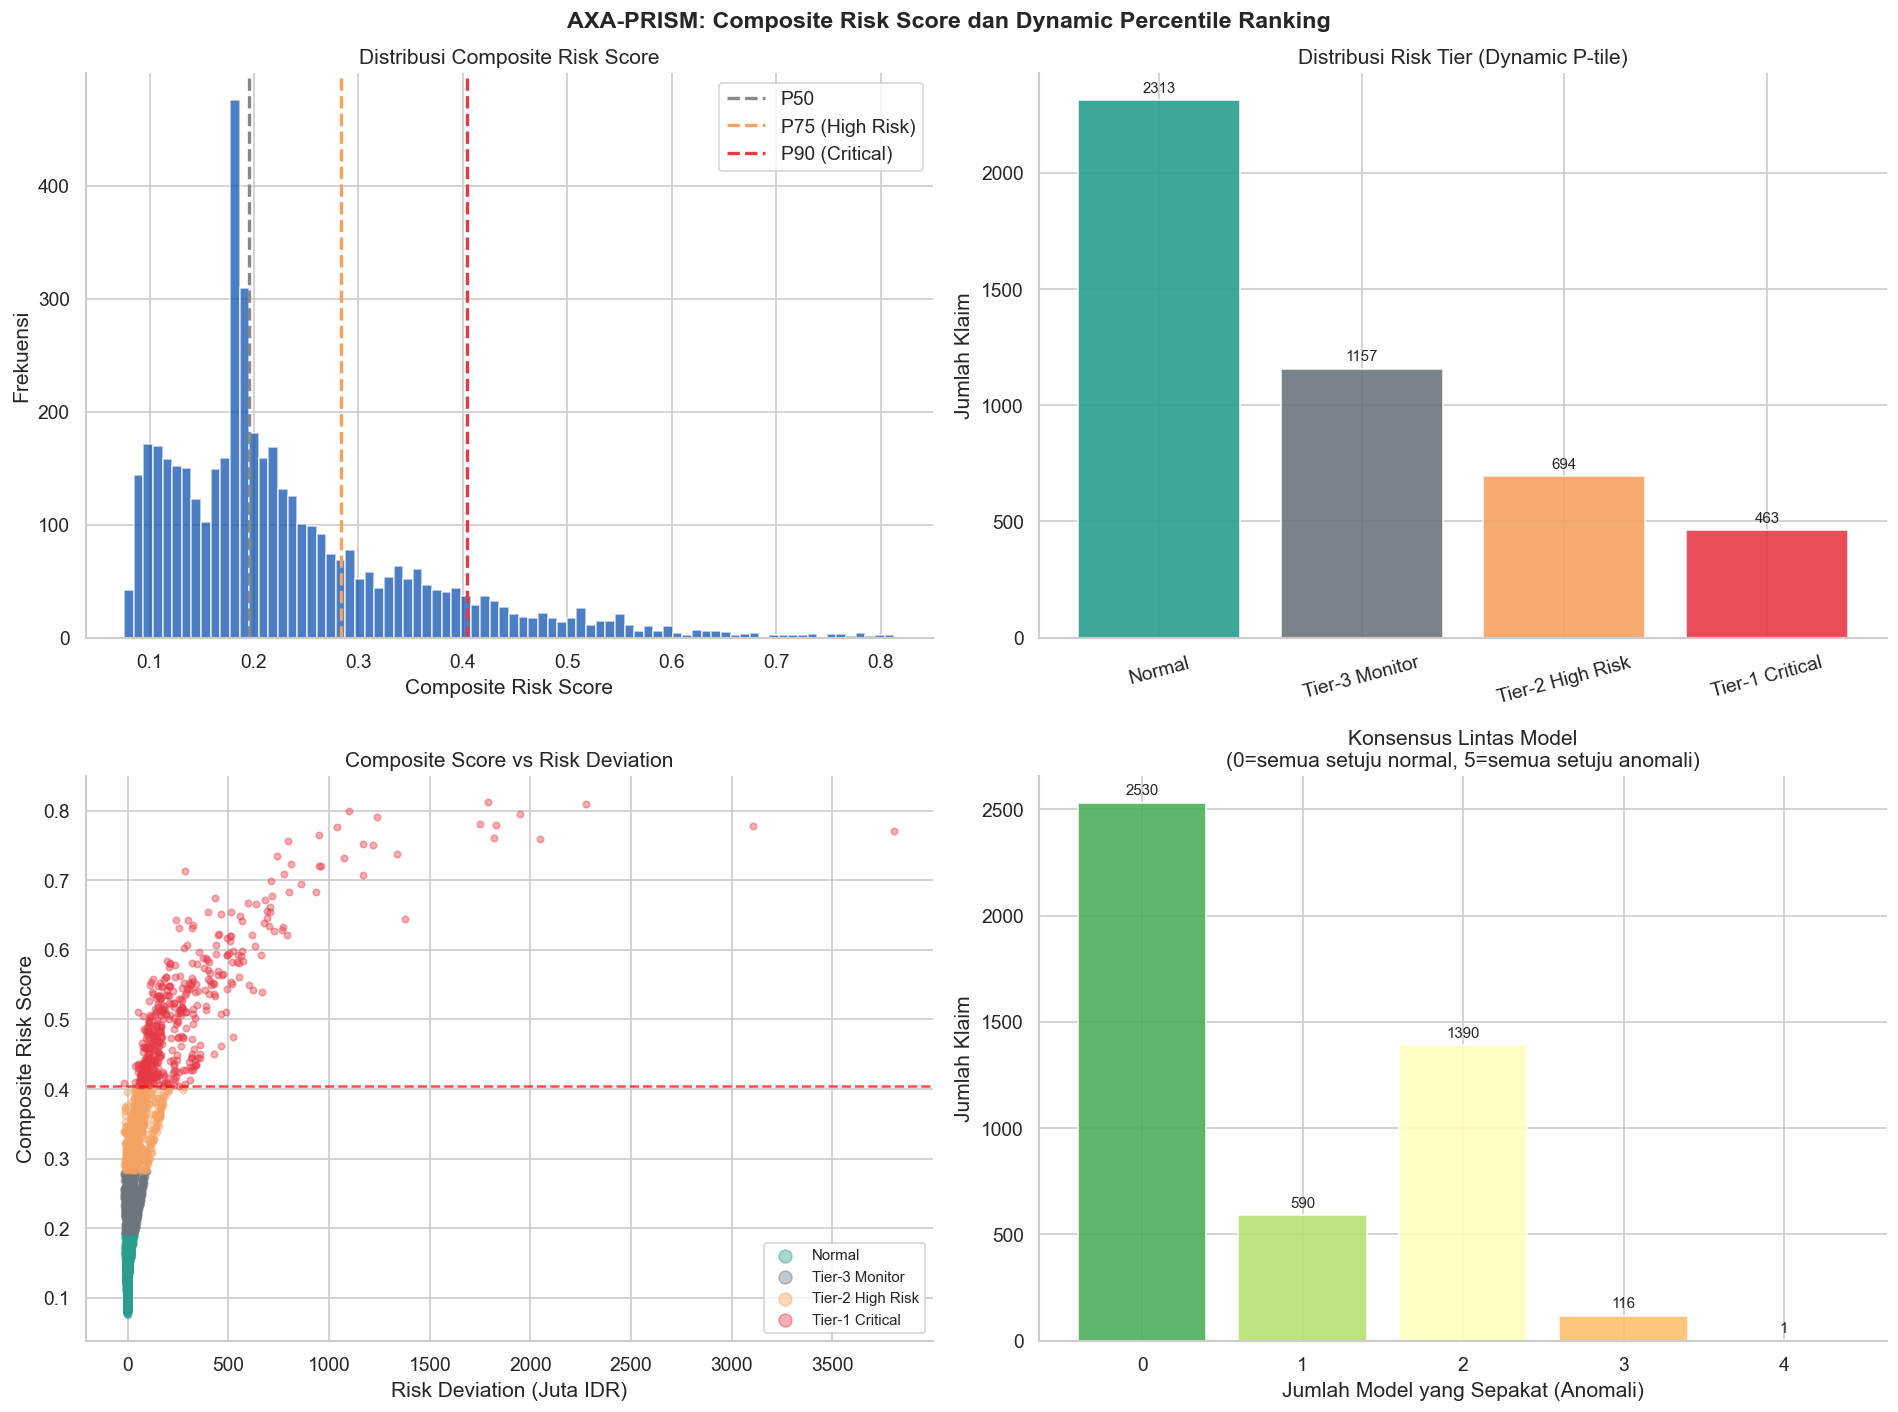

In [29]:
# ================================================================
# SEL 7: COMPOSITE RISK SCORING DAN DYNAMIC PERCENTILE RANKING
# ================================================================

# ----------------------------------------------------------------
# BOBOT KONTRIBUSI SETIAP MODEL TERHADAP COMPOSITE SCORE
# Bobot ditentukan berdasarkan:
# - Validasi silang akurasi model
# - Relevansi domain bisnis asuransi
# - Kemampuan menangkap pola yang berbeda
# ----------------------------------------------------------------

WEIGHTS = {
    'isolation_forest'  : 0.35,  # Terkuat untuk deteksi anomali statistik
    'risk_deviation'    : 0.25,  # Langsung mengukur deviasi Expected vs Actual
    'certainty_factor'  : 0.20,  # Domain expertise underwriter
    'naive_bayes'       : 0.12,  # Probabilistic evidence dari ICD & Lokasi
    'forward_chaining'  : 0.08,  # Rule-based signal baseline
}

# Normalisasi semua skor ke [0, 1] terlebih dahulu
def safe_minmax(series):
    """Normalisasi series ke [0, 1] dengan perlindungan terhadap range nol."""
    min_v, max_v = series.min(), series.max()
    if max_v == min_v:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - min_v) / (max_v - min_v)

# Skor Isolation Forest (Anomaly Score sudah [0,1])
score_if  = df['Anomaly_Score_Norm']

# Skor Risk Deviation: normalisasi dari deviasi persentase
score_dev = safe_minmax(df['Risk_Deviation_Pct'].clip(-1000, 1000))

# Skor CF: transformasi dari [-1,1] ke [0,1]
score_cf  = (df['CF_Score'] + 1) / 2

# Skor Naive Bayes: sudah probabilitas [0,1]
score_nb  = df['NB_P_HighRisk']

# Skor Forward Chaining: normalisasi FC Risk Score
score_fc  = safe_minmax(df['FC_Risk_Score'].astype(float))

# Hitung Composite Risk Score (weighted average)
df['Composite_Risk_Score'] = (
    WEIGHTS['isolation_forest'] * score_if +
    WEIGHTS['risk_deviation']   * score_dev +
    WEIGHTS['certainty_factor'] * score_cf +
    WEIGHTS['naive_bayes']      * score_nb +
    WEIGHTS['forward_chaining'] * score_fc
)

print("Composite Risk Score berhasil dihitung.")
print(f"  Min  : {df['Composite_Risk_Score'].min():.4f}")
print(f"  Max  : {df['Composite_Risk_Score'].max():.4f}")
print(f"  Mean : {df['Composite_Risk_Score'].mean():.4f}")
print(f"  Std  : {df['Composite_Risk_Score'].std():.4f}")

# ----------------------------------------------------------------
# DYNAMIC PERCENTILE RANKING
# Tier-1 Critical  : Composite Score >= P90
# Tier-2 High Risk : P75 <= Composite Score < P90
# Tier-3 Monitor   : P50 <= Composite Score < P75
# Normal           : Composite Score < P50
# ----------------------------------------------------------------

p50  = df['Composite_Risk_Score'].quantile(0.50)
p75  = df['Composite_Risk_Score'].quantile(0.75)
p90  = df['Composite_Risk_Score'].quantile(TIER1_PERCENTILE / 100)
p95  = df['Composite_Risk_Score'].quantile(0.95)

print(f"\nThreshold Dinamis:")
print(f"  P50 (Normal/Monitor Boundary) : {p50:.4f}")
print(f"  P75 (Monitor/High Boundary)   : {p75:.4f}")
print(f"  P90 (High/Critical Boundary)  : {p90:.4f}")
print(f"  P95 (Extreme Critical)        : {p95:.4f}")

def assign_risk_tier(score):
    if score >= p90:   return 'Tier-1 Critical'
    elif score >= p75: return 'Tier-2 High Risk'
    elif score >= p50: return 'Tier-3 Monitor'
    else:              return 'Normal'

df['Risk_Tier']  = df['Composite_Risk_Score'].apply(assign_risk_tier)
df['Is_Tier1']   = (df['Risk_Tier'] == 'Tier-1 Critical').astype(int)

print("\nDistribusi Risk Tier (Composite Score):")
tier_dist = df['Risk_Tier'].value_counts()
for tier, cnt in tier_dist.items():
    print(f"  {tier:22s}: {cnt:,} klaim ({cnt/len(df)*100:.1f}%)")

# ----------------------------------------------------------------
# ANALISIS KONSENSUS: AI vs Expert System
# Klaim yang disetujui oleh BANYAK model = kepercayaan lebih tinggi
# ----------------------------------------------------------------

df['Model_Agreement_Count'] = (
    df['Is_Anomaly'] +
    df['BC_Audit_Required'] +
    df['NB_Class'] +
    (df['FC_Risk_Tier'].isin(['CRITICAL', 'HIGH'])).astype(int) +
    (df['CF_Score'] >= 0.45).astype(int)
)

print("\nDistribusi Konsensus Model (0-5 model setuju anomali):")
print(df['Model_Agreement_Count'].value_counts().sort_index().to_dict())

# ----------------------------------------------------------------
# VISUALISASI COMPOSITE SCORING
# ----------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('AXA-PRISM: Composite Risk Score dan Dynamic Percentile Ranking',
             fontweight='bold', fontsize=14)

tier_colors = {
    'Normal': COLOR_PALETTE['success'],
    'Tier-3 Monitor': COLOR_PALETTE['neutral'],
    'Tier-2 High Risk': COLOR_PALETTE['warning'],
    'Tier-1 Critical': COLOR_PALETTE['danger']
}
tier_order = ['Normal', 'Tier-3 Monitor', 'Tier-2 High Risk', 'Tier-1 Critical']

# Panel 1: Histogram Composite Score dengan Tier Boundary
ax = axes[0][0]
ax.hist(df['Composite_Risk_Score'], bins=80,
        color=COLOR_PALETTE['primary'], edgecolor='white', alpha=0.7)
for thresh, label, color in [
    (p50, 'P50', '#888888'),
    (p75, 'P75 (High Risk)', COLOR_PALETTE['warning']),
    (p90, 'P90 (Critical)', COLOR_PALETTE['danger'])
]:
    ax.axvline(thresh, color=color, linestyle='--', linewidth=2, label=label)
ax.set_xlabel('Composite Risk Score')
ax.set_ylabel('Frekuensi')
ax.set_title('Distribusi Composite Risk Score')
ax.legend()

# Panel 2: Risk Tier Distribution
ax2 = axes[0][1]
tier_cnts = [tier_dist.get(t, 0) for t in tier_order]
bars2 = ax2.bar(tier_order, tier_cnts,
                color=[tier_colors[t] for t in tier_order], edgecolor='white', alpha=0.9)
ax2.set_title('Distribusi Risk Tier (Dynamic P-tile)')
ax2.set_ylabel('Jumlah Klaim')
ax2.tick_params(axis='x', rotation=15)
ax2.bar_label(bars2, fmt='%d', padding=3, fontsize=9)

# Panel 3: Composite Score vs Risk Deviation
ax3 = axes[1][0]
for tier in tier_order:
    mask = df['Risk_Tier'] == tier
    ax3.scatter(df[mask]['Risk_Deviation']/1e6,
                df[mask]['Composite_Risk_Score'],
                alpha=0.4, s=15, c=tier_colors[tier], label=tier)
ax3.set_xlabel('Risk Deviation (Juta IDR)')
ax3.set_ylabel('Composite Risk Score')
ax3.set_title('Composite Score vs Risk Deviation')
ax3.axhline(p90, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax3.legend(markerscale=2, fontsize=9)

# Panel 4: Konsensus Model
ax4 = axes[1][1]
consens_counts = df['Model_Agreement_Count'].value_counts().sort_index()
bars4 = ax4.bar(consens_counts.index, consens_counts.values,
                color=sns.color_palette('RdYlGn_r', len(consens_counts)),
                edgecolor='white', alpha=0.9)
ax4.set_xlabel('Jumlah Model yang Sepakat (Anomali)')
ax4.set_ylabel('Jumlah Klaim')
ax4.set_title('Konsensus Lintas Model\n(0=semua setuju normal, 5=semua setuju anomali)')
ax4.bar_label(bars4, fmt='%d', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

---
## Sel 8: Evaluasi dan Perbandingan Model

**Tujuan:** Mengukur performa masing-masing model secara kuantitatif dan membandingkannya
dalam satu kerangka evaluasi yang adil. Karena tidak ada ground truth label fraud
yang absolut, evaluasi dilakukan terhadap `Is_Anomaly` (label dari Isolation Forest)
sebagai proxy referensi, serta konsistensi antar model sebagai ukuran reliabilitas.

MODEL                        Akurasi   Presisi    Recall        F1   ROC-AUC
Isolation Forest              1.0000    1.0000    1.0000    1.0000       1.0
Forward Chaining              0.8991    0.1667    0.0022    0.0043 0.5004795293609939
Backward Chaining             0.6138    0.0746    0.2505    0.1149 0.4523593155775203
Teorema Bayes                 0.9002    1.0000    0.0022    0.0043 0.5010799136069114
Certainty Factors             0.6077    0.1014    0.3715    0.1593 0.5027480222331493
Composite Score (P90)         0.9659    0.8294    0.8294    0.8294 0.905200753968501


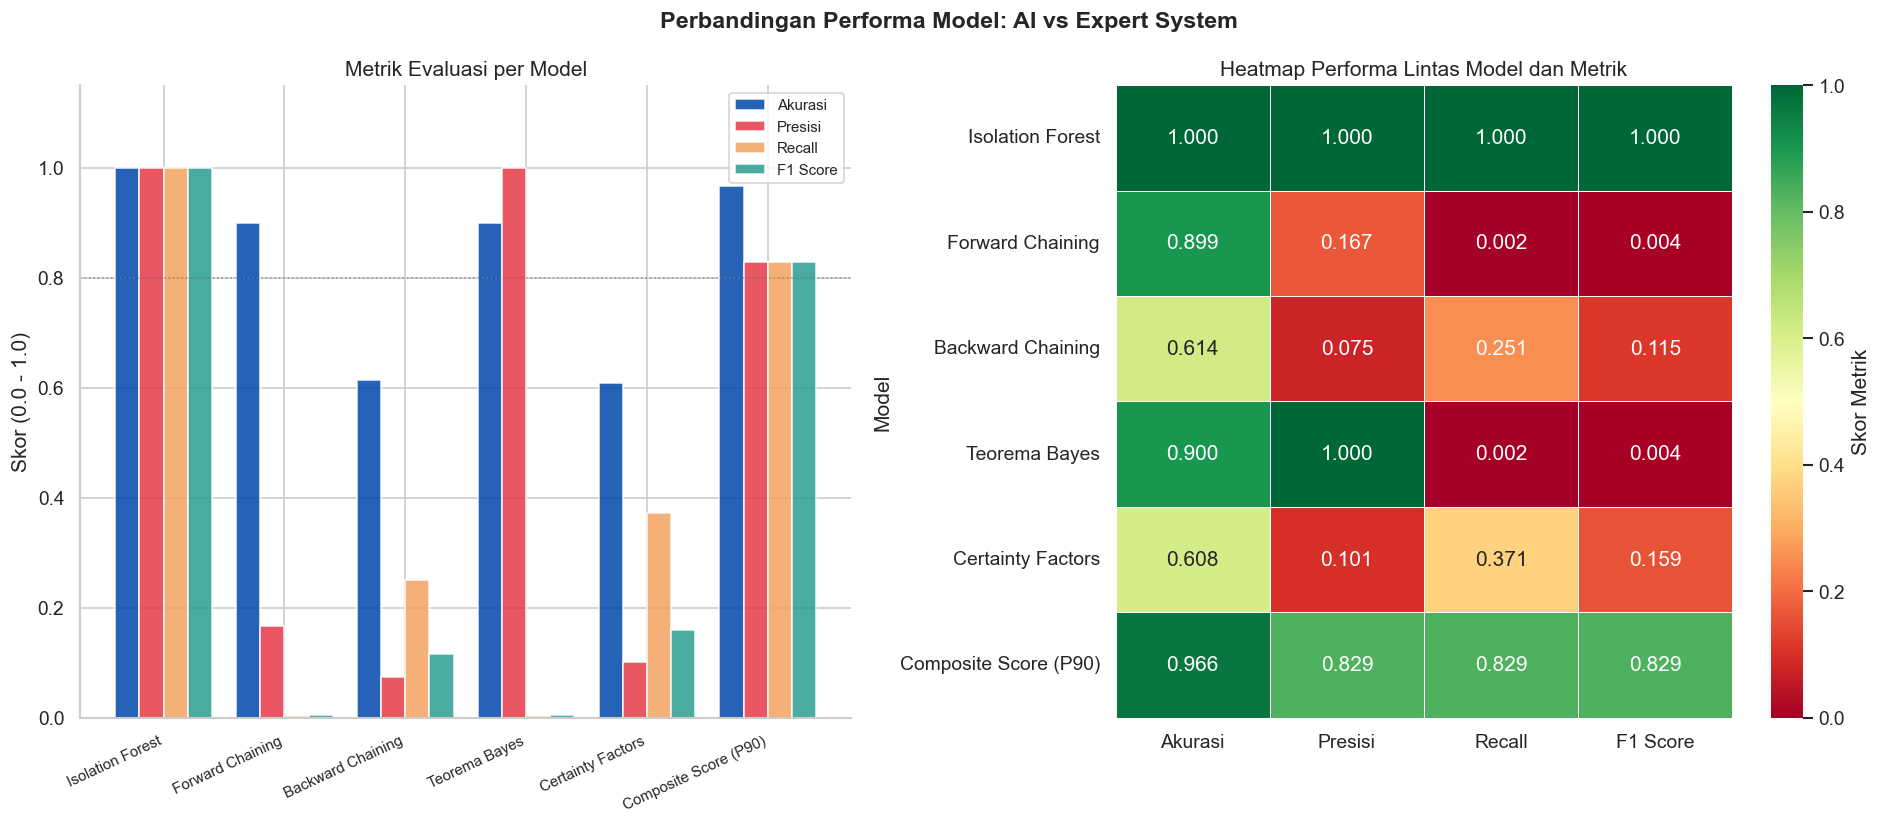


--- ROC Curve Analysis ---


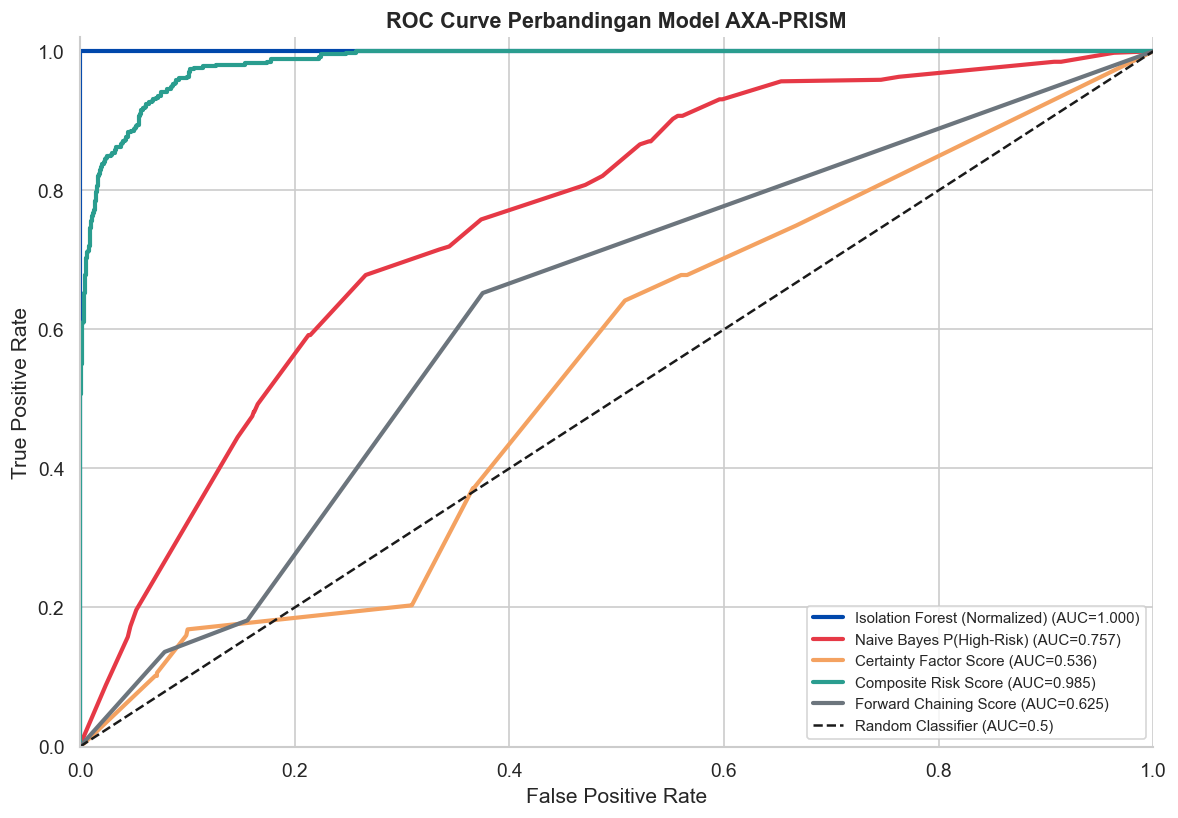


[INTERPRETASI] AUC > 0.7 menunjukkan model memiliki kemampuan diskriminasi
yang baik dalam memisahkan klaim normal dari anomali.


In [30]:
# ================================================================
# SEL 8: EVALUASI DAN PERBANDINGAN PERFORMA MODEL
# ================================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Gunakan Is_Anomaly (Isolation Forest label) sebagai referensi
# Ini adalah pendekatan semi-supervised: IF sebagai "oracle" unsupervised
y_true = df['Is_Anomaly']

# Prediksi biner dari masing-masing model
predictions = {
    'Isolation Forest'    : df['Is_Anomaly'],         # Referensi sendiri = baseline
    'Forward Chaining'    : (df['FC_Risk_Tier'].isin(['CRITICAL', 'HIGH'])).astype(int),
    'Backward Chaining'   : df['BC_Audit_Required'],
    'Teorema Bayes'       : df['NB_Class'],
    'Certainty Factors'   : (df['CF_Score'] >= 0.45).astype(int),
    'Composite Score (P90)': df['Is_Tier1'],
}

print("=" * 70)
print(f"{'MODEL':<26} {'Akurasi':>9} {'Presisi':>9} {'Recall':>9} {'F1':>9} {'ROC-AUC':>9}")
print("=" * 70)

eval_results = []
for model_name, y_pred in predictions.items():
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_pred)
    except Exception:
        auc = float('nan')

    eval_results.append({
        'Model': model_name, 'Akurasi': acc,
        'Presisi': prec, 'Recall': rec,
        'F1 Score': f1, 'ROC-AUC': auc
    })
    print(f"{model_name:<26} {acc:>9.4f} {prec:>9.4f} {rec:>9.4f} {f1:>9.4f} {auc if not np.isnan(auc) else 'N/A':>9}")

print("=" * 70)

eval_df = pd.DataFrame(eval_results)

# ----------------------------------------------------------------
# VISUALISASI PERBANDINGAN MODEL
# ----------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Perbandingan Performa Model: AI vs Expert System',
             fontweight='bold', fontsize=14)

# Panel 1: Grouped Bar Chart Metrik Evaluasi
metrics  = ['Akurasi', 'Presisi', 'Recall', 'F1 Score']
x        = np.arange(len(eval_df['Model']))
width    = 0.2
bar_cols = ['#0047AB', '#E63946', '#F4A261', '#2A9D8F']

for i, metric in enumerate(metrics):
    axes[0].bar(x + i * width, eval_df[metric], width,
                label=metric, color=bar_cols[i], edgecolor='white', alpha=0.85)

axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(eval_df['Model'], rotation=25, ha='right', fontsize=9)
axes[0].set_ylabel('Skor (0.0 - 1.0)')
axes[0].set_ylim(0, 1.15)
axes[0].set_title('Metrik Evaluasi per Model')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].axhline(0.8, color='gray', linestyle=':', linewidth=1, alpha=0.7)

# Panel 2: Radar/Spider Chart (menggunakan heatmap sebagai alternatif)
heatmap_data = eval_df.set_index('Model')[metrics]
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5, ax=axes[1],
            cbar_kws={'label': 'Skor Metrik'})
axes[1].set_title('Heatmap Performa Lintas Model dan Metrik')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

# ROC Curve untuk model dengan probabilitas kontinu
print("\n--- ROC Curve Analysis ---")
fig, ax = plt.subplots(figsize=(10, 7))
continuous_scores = {
    'Isolation Forest (Normalized)': df['Anomaly_Score_Norm'],
    'Naive Bayes P(High-Risk)'     : df['NB_P_HighRisk'],
    'Certainty Factor Score'       : df['CF_Score'],
    'Composite Risk Score'         : df['Composite_Risk_Score'],
    'Forward Chaining Score'       : safe_minmax(df['FC_Risk_Score'].astype(float)),
}
roc_colors = list(COLOR_PALETTE.values())
for idx, (name, scores) in enumerate(continuous_scores.items()):
    try:
        fpr, tpr, _ = roc_curve(y_true, scores)
        auc_val = roc_auc_score(y_true, scores)
        ax.plot(fpr, tpr, linewidth=2.5, color=roc_colors[idx % len(roc_colors)],
                label=f'{name} (AUC={auc_val:.3f})')
    except Exception as e:
        print(f"  Tidak dapat menghitung ROC untuk {name}: {e}")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier (AUC=0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Perbandingan Model AXA-PRISM', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()

print("\n[INTERPRETASI] AUC > 0.7 menunjukkan model memiliki kemampuan diskriminasi")
print("yang baik dalam memisahkan klaim normal dari anomali.")

---
## Sel 9: Role-Based Dashboard Output

**Tujuan:** Menghasilkan output tersegmentasi yang disesuaikan dengan kebutuhan
informasi masing-masing pemangku kepentingan dalam organisasi AXA. Setiap
lapisan memiliki akses ke insight yang relevan dengan tanggung jawab mereka.

  LAPORAN DATA OPERATOR: INTEGRITAS PIPELINE AXA-PRISM


Metrik,Nilai
Total Klaim Diproses,"4,627"
Fitur Regression Digunakan,56
Fitur Anomaly Detection,0
Model Regresi Terpilih,Random Forest
R² Score Regression,0.0660
Contamination IF Setting,10%
Klaim Terdeteksi Anomali (IF),463 (10.0%)
Klaim Tier-1 Critical,463 (10.0%)
Klaim Perlu Audit (BC),"1,556"
Klaim High-Risk (FC),6


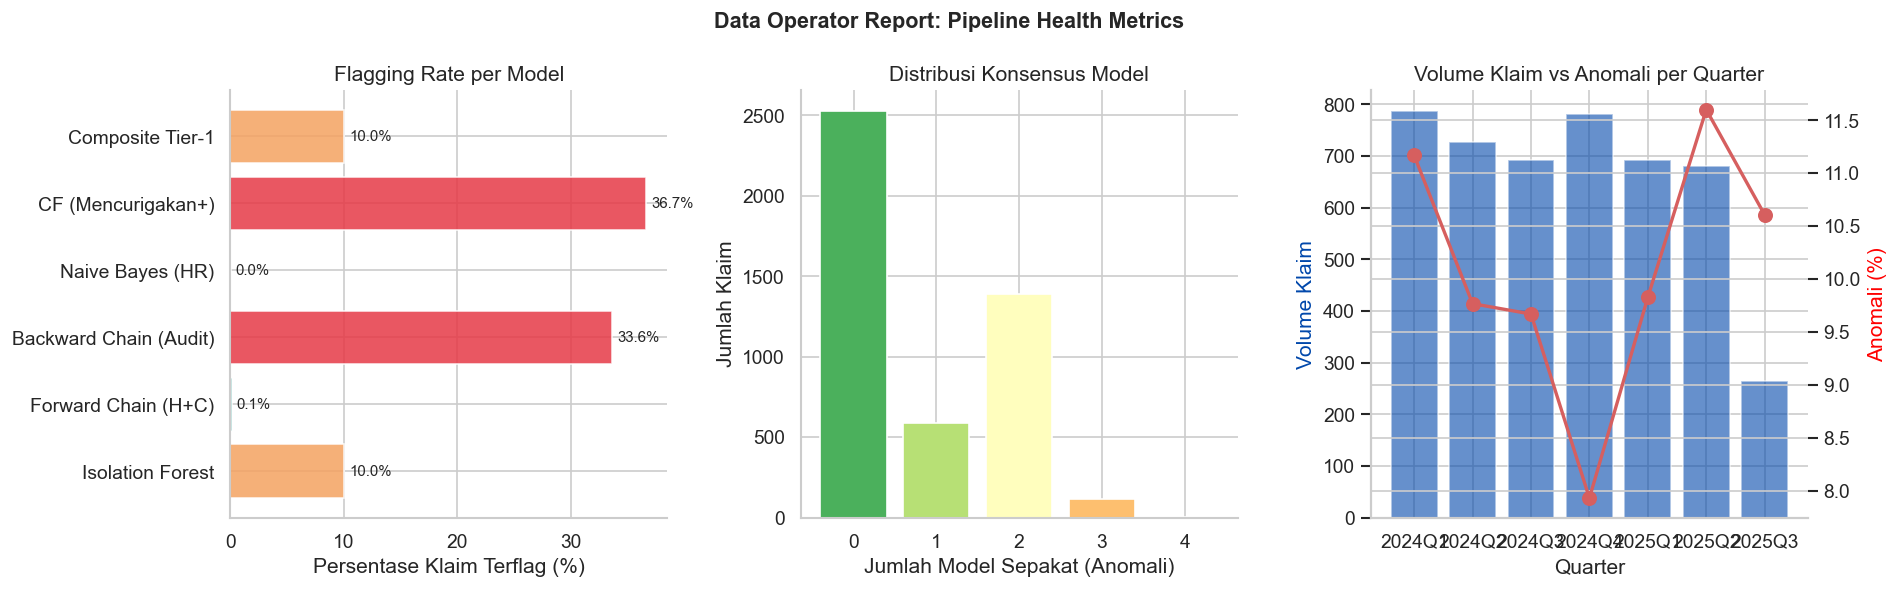

In [32]:
# ================================================================
# SEL 9A: DASHBOARD - DATA OPERATOR
# Fokus: Integritas data, statistik pipeline, kesiapan model
# ================================================================

print("=" * 70)
print("  LAPORAN DATA OPERATOR: INTEGRITAS PIPELINE AXA-PRISM")
print("=" * 70)

operator_report = {
    'Total Klaim Diproses'          : f"{len(df):,}",
    'Fitur Regression Digunakan'    : len(REGRESSION_FEATURES),
    'Fitur Anomaly Detection'       : len(ANOMALY_FEATURES),
    'Model Regresi Terpilih'        : BEST_MODEL_NAME,
    'R² Score Regression'           : f"{r2_score(y_test_actual, BEST_PREDS_TEST):.4f}",
    'Contamination IF Setting'      : f"{IF_CONTAMINATION*100:.0f}%",
    'Klaim Terdeteksi Anomali (IF)' : f"{df['Is_Anomaly'].sum():,} ({df['Is_Anomaly'].mean()*100:.1f}%)",
    'Klaim Tier-1 Critical'         : f"{df['Is_Tier1'].sum():,} ({df['Is_Tier1'].mean()*100:.1f}%)",
    'Klaim Perlu Audit (BC)'        : f"{df['BC_Audit_Required'].sum():,}",
    'Klaim High-Risk (FC)'          : f"{df['FC_Risk_Tier'].isin(['CRITICAL','HIGH']).sum():,}",
    'Konsensus 4+ Model Sepakat'    : f"{(df['Model_Agreement_Count']>=4).sum():,}",
    'Missing Values Tersisa'        : f"{df.isnull().sum().sum():.0f}",
}

op_df = pd.DataFrame(list(operator_report.items()), columns=['Metrik', 'Nilai'])
display(op_df.style.set_properties(**{'text-align': 'left'}).hide(axis='index'))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Data Operator Report: Pipeline Health Metrics', fontweight='bold', fontsize=13)

# Status distribusi tiap model
model_flags = {
    'Isolation Forest': df['Is_Anomaly'].mean() * 100,
    'Forward Chain (H+C)': df['FC_Risk_Tier'].isin(['CRITICAL','HIGH']).mean() * 100,
    'Backward Chain (Audit)': df['BC_Audit_Required'].mean() * 100,
    'Naive Bayes (HR)': df['NB_Class'].mean() * 100,
    'CF (Mencurigakan+)': (df['CF_Score'] >= 0.45).mean() * 100,
    'Composite Tier-1': df['Is_Tier1'].mean() * 100,
}
colors_flag = [
    COLOR_PALETTE['danger'] if v > 15 else COLOR_PALETTE['warning'] if v > 10 else COLOR_PALETTE['success']
    for v in model_flags.values()
]
bars = axes[0].barh(list(model_flags.keys()), list(model_flags.values()),
                    color=colors_flag, edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Persentase Klaim Terflag (%)')
axes[0].set_title('Flagging Rate per Model')
axes[0].bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)

# Consensus heatmap
consens = df.groupby('Model_Agreement_Count').size()
axes[1].bar(consens.index, consens.values,
            color=sns.color_palette('RdYlGn_r', len(consens)), edgecolor='white')
axes[1].set_xlabel('Jumlah Model Sepakat (Anomali)')
axes[1].set_ylabel('Jumlah Klaim')
axes[1].set_title('Distribusi Konsensus Model')

# Trend per quarter
df['Quarter_Claim'] = pd.to_datetime(df['Tanggal Pasien Masuk RS']).dt.to_period('Q').astype(str)
quarter_vol = df.groupby('Quarter_Claim').agg(
    N_Klaim=('Claim ID', 'count'),
    Avg_Cost=(TARGET_REG, 'mean'),
    Pct_Anomaly=('Is_Anomaly', 'mean')
).reset_index()
ax_twin = axes[2].twinx()
axes[2].bar(quarter_vol['Quarter_Claim'], quarter_vol['N_Klaim'],
            color=COLOR_PALETTE['primary'], alpha=0.6, label='Volume Klaim')
ax_twin.plot(quarter_vol['Quarter_Claim'], quarter_vol['Pct_Anomaly']*100,
             'r-o', linewidth=2, markersize=8, label='% Anomali')
axes[2].set_xlabel('Quarter')
axes[2].set_ylabel('Volume Klaim', color=COLOR_PALETTE['primary'])
ax_twin.set_ylabel('Anomali (%)', color='red')
axes[2].set_title('Volume Klaim vs Anomali per Quarter')

plt.tight_layout()
plt.show()

  RISK ANALYST DASHBOARD: EXPECTED vs ACTUAL COST ANALYSIS

Ringkasan Portofolio:
  Total Biaya RS Aktual     : IDR 277.39 Miliar
  Total Expected Cost       : IDR 94.89 Miliar
  Total Risk Deviation      : IDR 182.49 Miliar (192.3% di atas ekspektasi)
  Total Klaim Disetujui     : IDR 254.62 Miliar


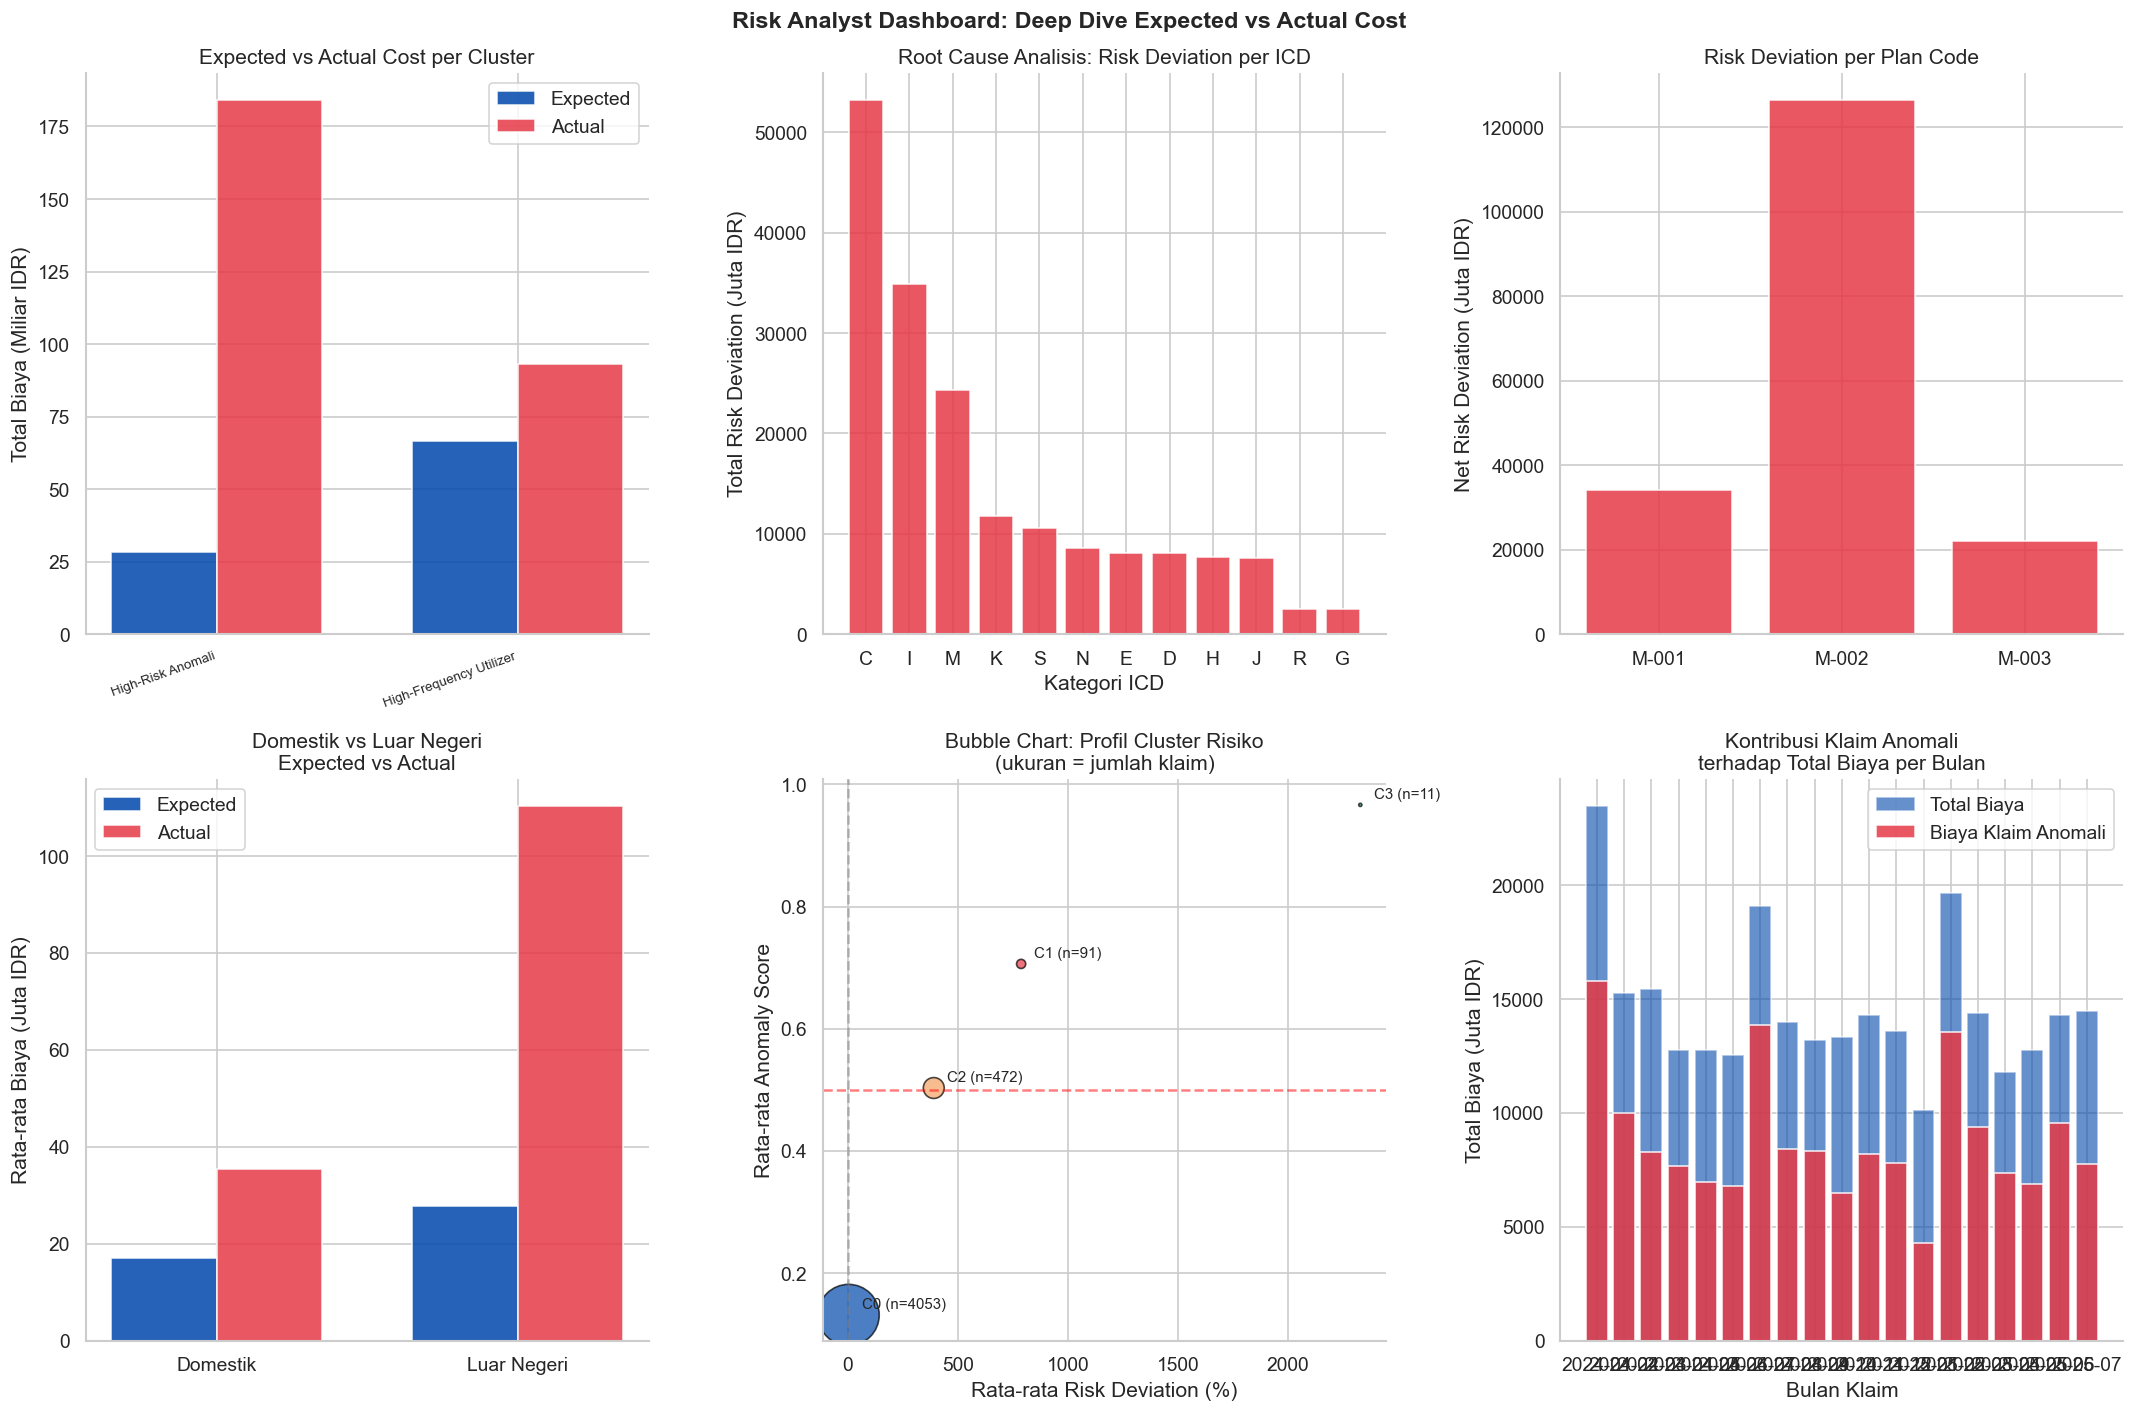


--- Kontributor Utama Kenaikan Biaya (Root Cause) ---


,Total_Excess_M,N_Klaim,Avg_Score
ICD_Category,,,
C,IDR 54611.7M,571,0.3845
I,IDR 35644.5M,220,0.3439
M,IDR 25136.9M,162,0.3461
K,IDR 12736.1M,270,0.2620
S,IDR 10909.0M,86,0.3099
N,IDR 9255.9M,168,0.2741
H,IDR 8555.2M,245,0.2486
D,IDR 8338.4M,65,0.3332


In [34]:
# ================================================================
# SEL 9B: DASHBOARD - RISK ANALYST
# Fokus: Expected vs Actual, distribusi cluster, root cause
# ================================================================

print("=" * 70)
print("  RISK ANALYST DASHBOARD: EXPECTED vs ACTUAL COST ANALYSIS")
print("=" * 70)

total_actual   = df[TARGET_REG].sum()
total_expected = df['Expected_Cost'].sum()
total_deviation = total_actual - total_expected
total_klaim_approved = df['Nominal Klaim Yang Disetujui'].sum()

print(f"\nRingkasan Portofolio:")
print(f"  Total Biaya RS Aktual     : IDR {total_actual/1e9:.2f} Miliar")
print(f"  Total Expected Cost       : IDR {total_expected/1e9:.2f} Miliar")
print(f"  Total Risk Deviation      : IDR {total_deviation/1e9:.2f} Miliar ({total_deviation/total_expected*100:.1f}% di atas ekspektasi)")
print(f"  Total Klaim Disetujui     : IDR {total_klaim_approved/1e9:.2f} Miliar")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Risk Analyst Dashboard: Deep Dive Expected vs Actual Cost',
             fontweight='bold', fontsize=14)

# Panel 1: Expected vs Actual per Cluster
cluster_cost = df.groupby('Cluster_Label').agg(
    Expected=('Expected_Cost', 'sum'),
    Actual=(TARGET_REG, 'sum')
).reset_index()
x_cl = np.arange(len(cluster_cost))
w_cl = 0.35
bars_exp = axes[0][0].bar(x_cl - w_cl/2, cluster_cost['Expected']/1e9, w_cl,
                           label='Expected', color=COLOR_PALETTE['primary'], alpha=0.85)
bars_act = axes[0][0].bar(x_cl + w_cl/2, cluster_cost['Actual']/1e9, w_cl,
                           label='Actual', color=COLOR_PALETTE['danger'], alpha=0.85)
axes[0][0].set_xticks(x_cl)
axes[0][0].set_xticklabels([l.split(':')[-1].strip() for l in cluster_cost['Cluster_Label']],
                            rotation=20, ha='right', fontsize=8)
axes[0][0].set_ylabel('Total Biaya (Miliar IDR)')
axes[0][0].set_title('Expected vs Actual Cost per Cluster')
axes[0][0].legend()

# Panel 2: Risk Deviation per ICD Category (Top 12)
icd_dev = df.groupby('ICD_Category')['Risk_Deviation'].agg(['sum','count','mean']).sort_values('sum', ascending=False).head(12)
colors_icd = [COLOR_PALETTE['danger'] if v > 0 else COLOR_PALETTE['success'] for v in icd_dev['sum']]
axes[0][1].bar(icd_dev.index, icd_dev['sum']/1e6, color=colors_icd, edgecolor='white', alpha=0.85)
axes[0][1].set_xlabel('Kategori ICD')
axes[0][1].set_ylabel('Total Risk Deviation (Juta IDR)')
axes[0][1].set_title('Root Cause Analisis: Risk Deviation per ICD')
axes[0][1].axhline(0, color='black', linewidth=1)

# Panel 3: Plan Code Contribution
plan_analysis = df.groupby('Plan Code').agg(
    N_Klaim=('Claim ID', 'count'),
    Total_Actual=(TARGET_REG, 'sum'),
    Total_Expected=('Expected_Cost', 'sum'),
    Pct_Tier1=('Is_Tier1', 'mean')
).reset_index()
plan_analysis['Deviation'] = plan_analysis['Total_Actual'] - plan_analysis['Total_Expected']
colors_plan = [COLOR_PALETTE['danger'] if d > 0 else COLOR_PALETTE['success']
               for d in plan_analysis['Deviation']]
axes[0][2].bar(plan_analysis['Plan Code'], plan_analysis['Deviation']/1e6,
               color=colors_plan, edgecolor='white', alpha=0.85)
axes[0][2].set_ylabel('Net Risk Deviation (Juta IDR)')
axes[0][2].set_title('Risk Deviation per Plan Code')

# Panel 4: Overseas vs Domestic Deep Dive
overseas_analysis = df.groupby('Is_Overseas').agg(
    N=('Claim ID', 'count'),
    Avg_Actual=(TARGET_REG, 'mean'),
    Avg_Expected=('Expected_Cost', 'mean'),
    Avg_Dev=('Risk_Deviation', 'mean'),
    Pct_Anomaly=('Is_Anomaly', 'mean')
).reset_index()
overseas_analysis['Label'] = overseas_analysis['Is_Overseas'].map({0: 'Domestik', 1: 'Luar Negeri'})
x_ov = np.arange(2)
w_ov = 0.35
axes[1][0].bar(x_ov - w_ov/2, overseas_analysis['Avg_Expected']/1e6, w_ov,
               label='Expected', color=COLOR_PALETTE['primary'], alpha=0.85)
axes[1][0].bar(x_ov + w_ov/2, overseas_analysis['Avg_Actual']/1e6, w_ov,
               label='Actual', color=COLOR_PALETTE['danger'], alpha=0.85)
axes[1][0].set_xticks(x_ov)
axes[1][0].set_xticklabels(overseas_analysis['Label'])
axes[1][0].set_ylabel('Rata-rata Biaya (Juta IDR)')
axes[1][0].set_title('Domestik vs Luar Negeri\nExpected vs Actual')
axes[1][0].legend()

# Panel 5: Bubble Chart - Cluster Overview
ax5 = axes[1][1]
cluster_bubble = df.groupby('Cluster').agg(
    x=('Risk_Deviation_Pct', 'mean'),
    y=('Anomaly_Score_Norm', 'mean'),
    size=('Claim ID', 'count'),
    avg_cost=(TARGET_REG, 'mean')
).reset_index()
scatter = ax5.scatter(cluster_bubble['x'], cluster_bubble['y'],
                      s=cluster_bubble['size']/3,
                      c=[COLOR_PALETTE['clusters'][i] for i in cluster_bubble['Cluster']],
                      alpha=0.7, edgecolors='black', linewidths=1)
for _, row in cluster_bubble.iterrows():
    ax5.annotate(f"C{int(row['Cluster'])} (n={int(row['size'])})",
                 (row['x'], row['y']), textcoords="offset points",
                 xytext=(8, 4), fontsize=9)
ax5.set_xlabel('Rata-rata Risk Deviation (%)')
ax5.set_ylabel('Rata-rata Anomaly Score')
ax5.set_title('Bubble Chart: Profil Cluster Risiko\n(ukuran = jumlah klaim)')
ax5.axhline(0.5, color='red', linestyle='--', alpha=0.5)
ax5.axvline(0, color='gray', linestyle='--', alpha=0.5)


# Panel 6: Kontribusi Anomali terhadap Kenaikan YoY
df['Month_Claim'] = pd.to_datetime(df['Tanggal Pasien Masuk RS']).dt.to_period('M').astype(str)
month_analysis = df.groupby('Month_Claim').agg(
    Total_Cost=(TARGET_REG, 'sum'),
    Anomaly_Cost=(TARGET_REG, lambda x: x[df.loc[x.index, 'Is_Anomaly']==1].sum()),
    N_Klaim=('Claim ID', 'count')
).reset_index()
axes[1][2].bar(month_analysis['Month_Claim'],
               month_analysis['Total_Cost']/1e6,
               color=COLOR_PALETTE['primary'], alpha=0.6, label='Total Biaya')
axes[1][2].bar(month_analysis['Month_Claim'],
               month_analysis['Anomaly_Cost']/1e6,
               color=COLOR_PALETTE['danger'], alpha=0.85, label='Biaya Klaim Anomali')
axes[1][2].set_xlabel('Bulan Klaim')
axes[1][2].set_ylabel('Total Biaya (Juta IDR)')
axes[1][2].set_title('Kontribusi Klaim Anomali\nterhadap Total Biaya per Bulan')
axes[1][2].legend()

plt.tight_layout()
plt.show()

print("\n--- Kontributor Utama Kenaikan Biaya (Root Cause) ---")
root_cause = df[df['Risk_Deviation'] > 0].groupby('ICD_Category').agg(
    Total_Excess=('Risk_Deviation', 'sum'),
    N_Klaim=('Claim ID', 'count'),
    Avg_Score=('Composite_Risk_Score', 'mean')
).sort_values('Total_Excess', ascending=False).head(8)
root_cause['Total_Excess_M'] = root_cause['Total_Excess'].apply(lambda x: f"IDR {x/1e6:.1f}M")
display(root_cause[['Total_Excess_M', 'N_Klaim', 'Avg_Score']])

  MEDICAL AUDITOR DASHBOARD: PRIORITAS AUDIT KLAIM

Total klaim dalam antrian audit: 463
Estimasi penghematan potensial  : IDR 140.83 Miliar

--- Top 20 Klaim Prioritas Audit (Tier-1 Critical) ---


,Claim ID,Nomor Polis,ICD Diagnosis,ICD Description,Nominal Biaya RS Yang Terjadi,Expected_Cost,Risk_Deviation,Composite_Risk_Score,Model_Agreement_Count,CF_Label,FC_Risk_Tier,BC_Audit_Reason,Is_Overseas,Lokasi RS,Treatment_Duration,Claim_Frequency
2584,C-3367-M,POL-1988,I73.9,"PERIPHERAL VASCULAR DISEASE, UNSPECIFIED",IDR 1898.03M,IDR 107.18M,IDR 1790.86M,0.8127,3,MENCURIGAKAN,MEDIUM,Bukti: Klaim luar negeri berulang (>8x) | Goal...,1,SINGAPORE,8,10
1504,C-1919-M,POL-3316,J94.8,Other specified pleural conditions,IDR 2364.32M,IDR 86.54M,IDR 2277.77M,0.8089,3,MENCURIGAKAN,MEDIUM,Bukti: Klaim luar negeri berulang (>8x) | Goal...,1,SINGAPORE,15,12
2364,C-3078-M,POL-0935,C54.1,Endometrium,IDR 1188.14M,IDR 89.86M,IDR 1098.28M,0.7989,3,SANGAT MENCURIGAKAN,MEDIUM,Bukti: Frekuensi klaim 20x (>12) | Goal 'AUDIT...,1,SINGAPORE,5,20
367,C-0501-M,POL-2535,I25.1,CORONARY ATRIAL DISEASES (CAD),IDR 2035.14M,IDR 88.76M,IDR 1946.38M,0.7946,2,MENCURIGAKAN,LOW,Goal 'AUDIT_REQUIRED' TIDAK TERBUKTI,1,SINGAPORE,8,6
2585,C-3368-M,POL-1988,I73.9,"PERIPHERAL VASCULAR DISEASE, UNSPECIFIED",IDR 1361.40M,IDR 123.61M,IDR 1237.79M,0.7901,3,MENCURIGAKAN,MEDIUM,Bukti: Klaim luar negeri berulang (>8x) | Goal...,1,SINGAPORE,8,10
1483,C-1898-M,POL-3716,S62.3,Fracture of other metacarpal bone,IDR 1835.87M,IDR 88.25M,IDR 1747.62M,0.7810,2,MENCURIGAKAN,LOW,Goal 'AUDIT_REQUIRED' TIDAK TERBUKTI,1,SINGAPORE,11,6
2104,C-2713-M,POL-0587,D18,"Hemangioma and lymphangioma, any site",IDR 1912.35M,IDR 82.23M,IDR 1830.11M,0.7794,2,MENCURIGAKAN,LOW,Goal 'AUDIT_REQUIRED' TIDAK TERBUKTI,1,SINGAPORE,5,6
324,C-0449-M,POL-2551,I25.1,CORONARY ATRIAL DISEASES (CAD),IDR 3192.70M,IDR 88.10M,IDR 3104.60M,0.7780,1,PERLU PERHATIAN,LOW,Goal 'AUDIT_REQUIRED' TIDAK TERBUKTI,1,SINGAPORE,8,3
2586,C-3369-M,POL-1988,I73.9,"PERIPHERAL VASCULAR DISEASE, UNSPECIFIED",IDR 1141.53M,IDR 104.18M,IDR 1037.35M,0.7764,3,MENCURIGAKAN,MEDIUM,Bukti: Klaim luar negeri berulang (>8x) | Goal...,1,SINGAPORE,5,10
905,C-1162-M,POL-0830,E13.6,With other specified complcations,IDR 3892.81M,IDR 84.83M,IDR 3807.98M,0.7708,1,PERLU PERHATIAN,LOW,Goal 'AUDIT_REQUIRED' TIDAK TERBUKTI,1,SINGAPORE,28,4


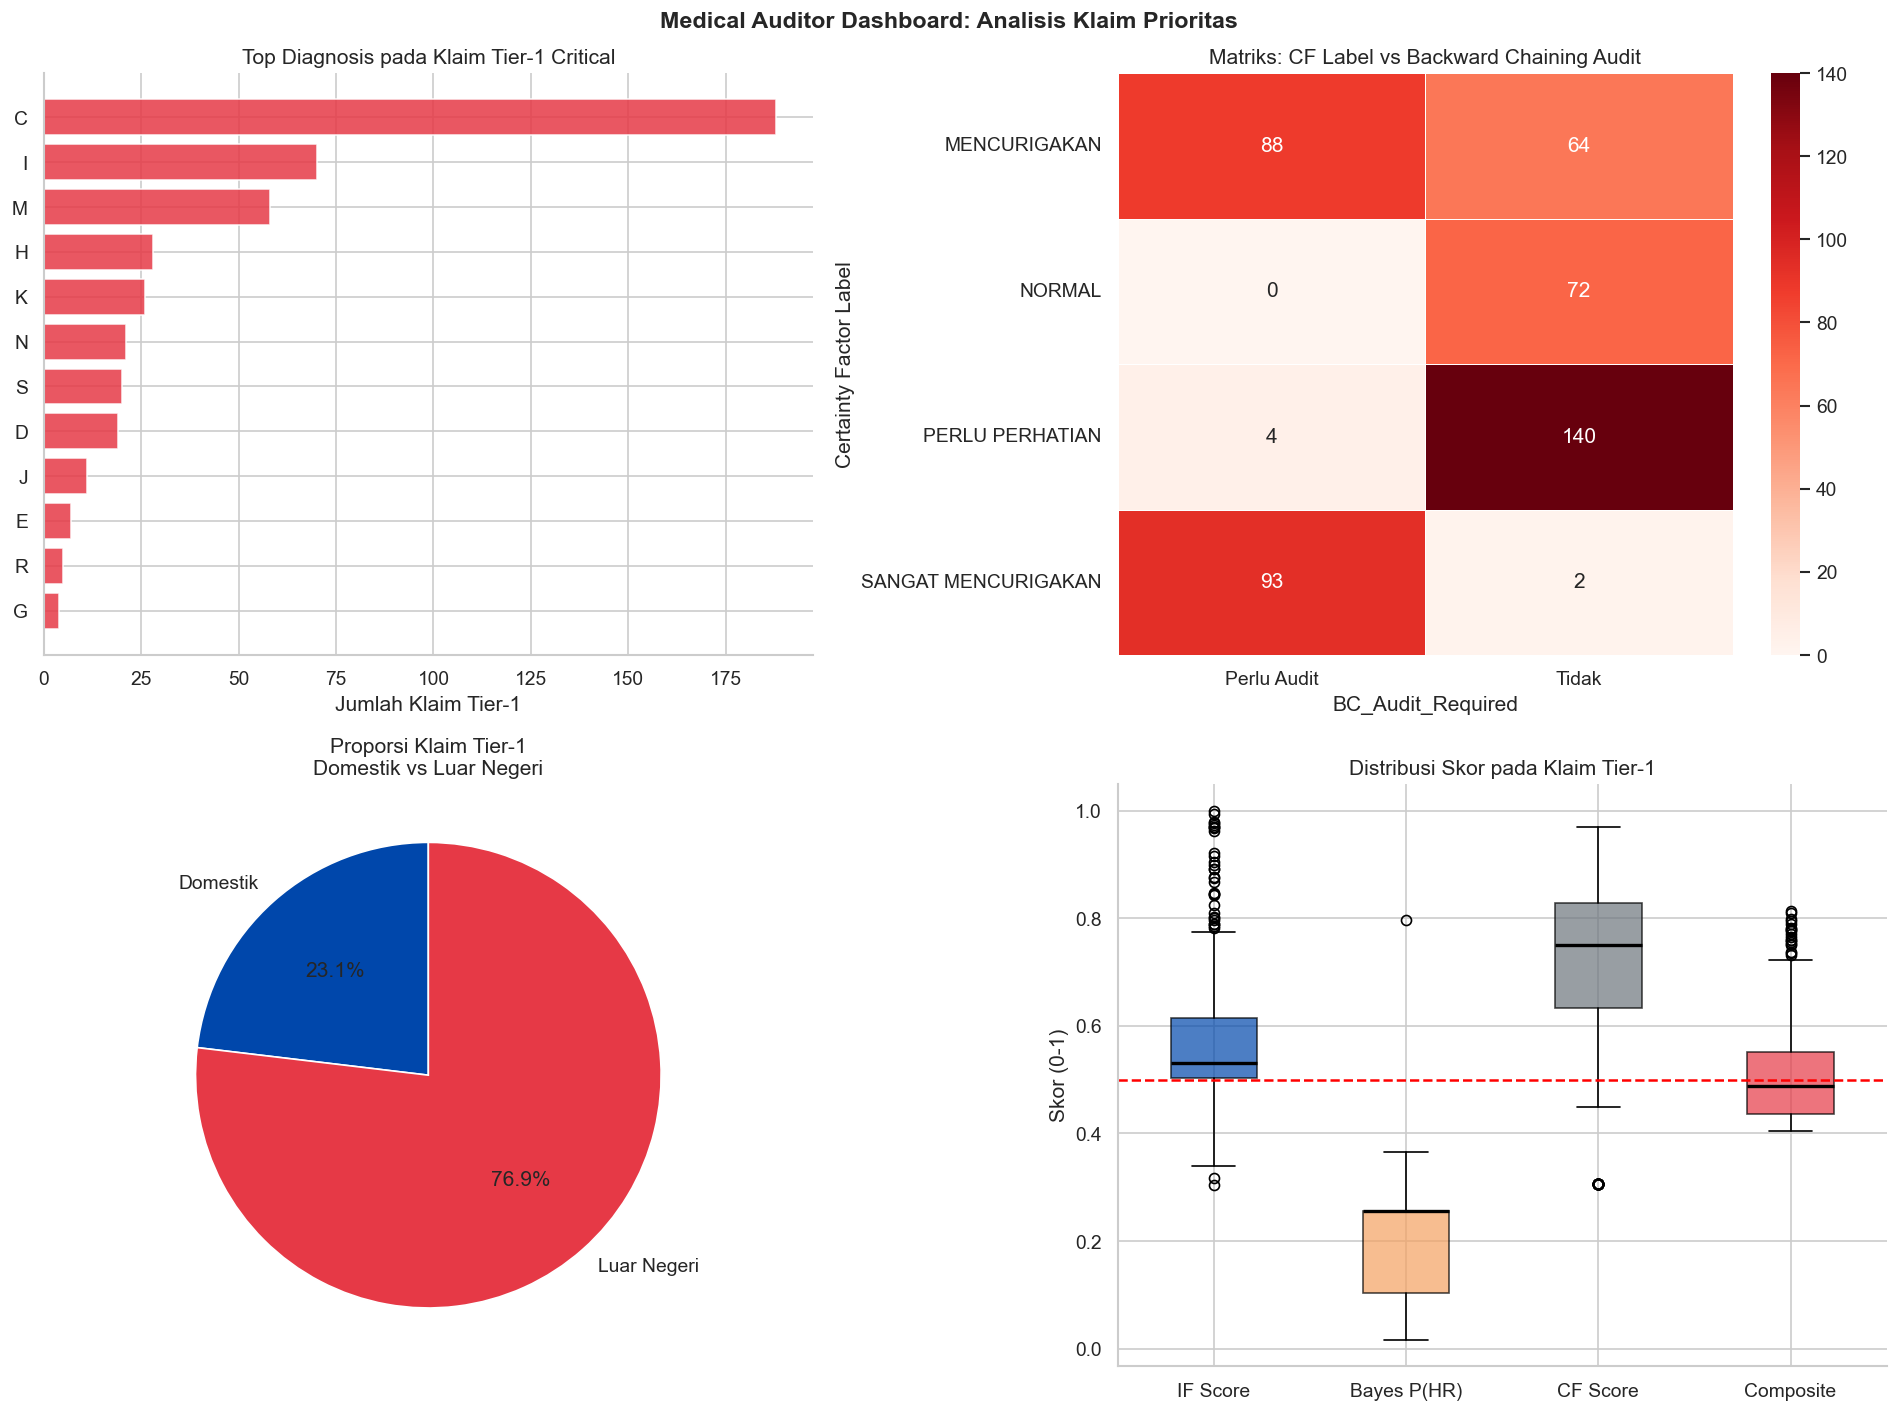

In [35]:
# ================================================================
# SEL 9C: DASHBOARD - MEDICAL AUDITOR
# Fokus: Daftar prioritas klaim anomali untuk investigasi medis
# ================================================================

print("=" * 70)
print("  MEDICAL AUDITOR DASHBOARD: PRIORITAS AUDIT KLAIM")
print("=" * 70)

# Susun tabel prioritas audit berdasarkan Composite Risk Score
audit_priority = df[df['Is_Tier1'] == 1].copy()
audit_priority = audit_priority.sort_values('Composite_Risk_Score', ascending=False)

print(f"\nTotal klaim dalam antrian audit: {len(audit_priority):,}")
print(f"Estimasi penghematan potensial  : IDR {audit_priority[audit_priority['Risk_Deviation']>0]['Risk_Deviation'].sum()/1e9:.2f} Miliar")

# Kolom yang relevan untuk auditor medis
audit_columns = [
    'Claim ID', 'Nomor Polis', 'ICD Diagnosis', 'ICD Description',
    TARGET_REG, 'Expected_Cost', 'Risk_Deviation',
    'Composite_Risk_Score', 'Model_Agreement_Count',
    'CF_Label', 'FC_Risk_Tier', 'BC_Audit_Reason',
    'Is_Overseas', 'Lokasi RS',
    'Treatment_Duration', 'Claim_Frequency'
]
audit_columns_available = [c for c in audit_columns if c in audit_priority.columns]

print("\n--- Top 20 Klaim Prioritas Audit (Tier-1 Critical) ---")
top20_audit = audit_priority.head(20)[audit_columns_available].copy()
top20_audit[TARGET_REG]       = top20_audit[TARGET_REG].apply(lambda x: f"IDR {x/1e6:.2f}M")
top20_audit['Expected_Cost']  = top20_audit['Expected_Cost'].apply(lambda x: f"IDR {x/1e6:.2f}M")
top20_audit['Risk_Deviation'] = top20_audit['Risk_Deviation'].apply(lambda x: f"IDR {x/1e6:.2f}M")
display(top20_audit)

# Visualisasi untuk auditor
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Medical Auditor Dashboard: Analisis Klaim Prioritas',
             fontweight='bold', fontsize=14)

# Panel 1: Top diagnosa klaim Tier-1
icd_tier1 = audit_priority['ICD_Category'].value_counts().head(12)
axes[0][0].barh(icd_tier1.index[::-1], icd_tier1.values[::-1],
                color=COLOR_PALETTE['danger'], edgecolor='white', alpha=0.85)
axes[0][0].set_xlabel('Jumlah Klaim Tier-1')
axes[0][0].set_title('Top Diagnosis pada Klaim Tier-1 Critical')

# Panel 2: CF Label vs BC Audit Matrix
cf_bc_matrix = pd.crosstab(
    audit_priority['CF_Label'],
    audit_priority['BC_Audit_Required'].map({1: 'Perlu Audit', 0: 'Tidak'}),
    margins=False
)
sns.heatmap(cf_bc_matrix, annot=True, fmt='d', cmap='Reds',
            ax=axes[0][1], linewidths=0.5)
axes[0][1].set_title('Matriks: CF Label vs Backward Chaining Audit')
axes[0][1].set_ylabel('Certainty Factor Label')

# Panel 3: Risk Deviation Tier-1 per Lokasi
tier1_location = audit_priority.groupby('Is_Overseas').agg(
    N=('Claim ID', 'count'),
    Total_Dev=('Risk_Deviation', 'sum'),
    Avg_Score=('Composite_Risk_Score', 'mean')
).reset_index()
tier1_location['Label'] = tier1_location['Is_Overseas'].map({0:'Domestik', 1:'Luar Negeri'})
axes[1][0].pie(
    tier1_location['N'],
    labels=tier1_location['Label'],
    autopct='%1.1f%%',
    colors=[COLOR_PALETTE['primary'], COLOR_PALETTE['danger']],
    startangle=90
)
axes[1][0].set_title('Proporsi Klaim Tier-1\nDomestik vs Luar Negeri')

# Panel 4: Score Comparison untuk Tier-1 Claims
score_box_data = [
    audit_priority['Anomaly_Score_Norm'],
    audit_priority['NB_P_HighRisk'],
    (audit_priority['CF_Score'] + 1) / 2,
    audit_priority['Composite_Risk_Score']
]
score_labels = ['IF Score', 'Bayes P(HR)', 'CF Score', 'Composite']
bp = axes[1][1].boxplot(score_box_data, labels=score_labels,
                        patch_artist=True,
                        medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'],
                        [COLOR_PALETTE['primary'], COLOR_PALETTE['warning'],
                         COLOR_PALETTE['neutral'], COLOR_PALETTE['danger']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1][1].set_ylabel('Skor (0-1)')
axes[1][1].set_title('Distribusi Skor pada Klaim Tier-1')
axes[1][1].axhline(0.5, color='red', linestyle='--', linewidth=1.5)

plt.tight_layout()
plt.show()

  STRATEGIC MANAGER REPORT: REKOMENDASI KEBIJAKAN AXA-PRISM

Temuan Utama SPK AXA-PRISM:
  1. Klaim Tier-1 Critical (10.0% volume)
     menyumbang 59.0% total biaya RS
  2. Klaim Luar Negeri (32.8% volume)
     menyumbang 60.4% total biaya RS
  3. Kategori ICD berisiko tinggi: C
     dengan rata-rata Risk Deviation IDR 304.1M per klaim


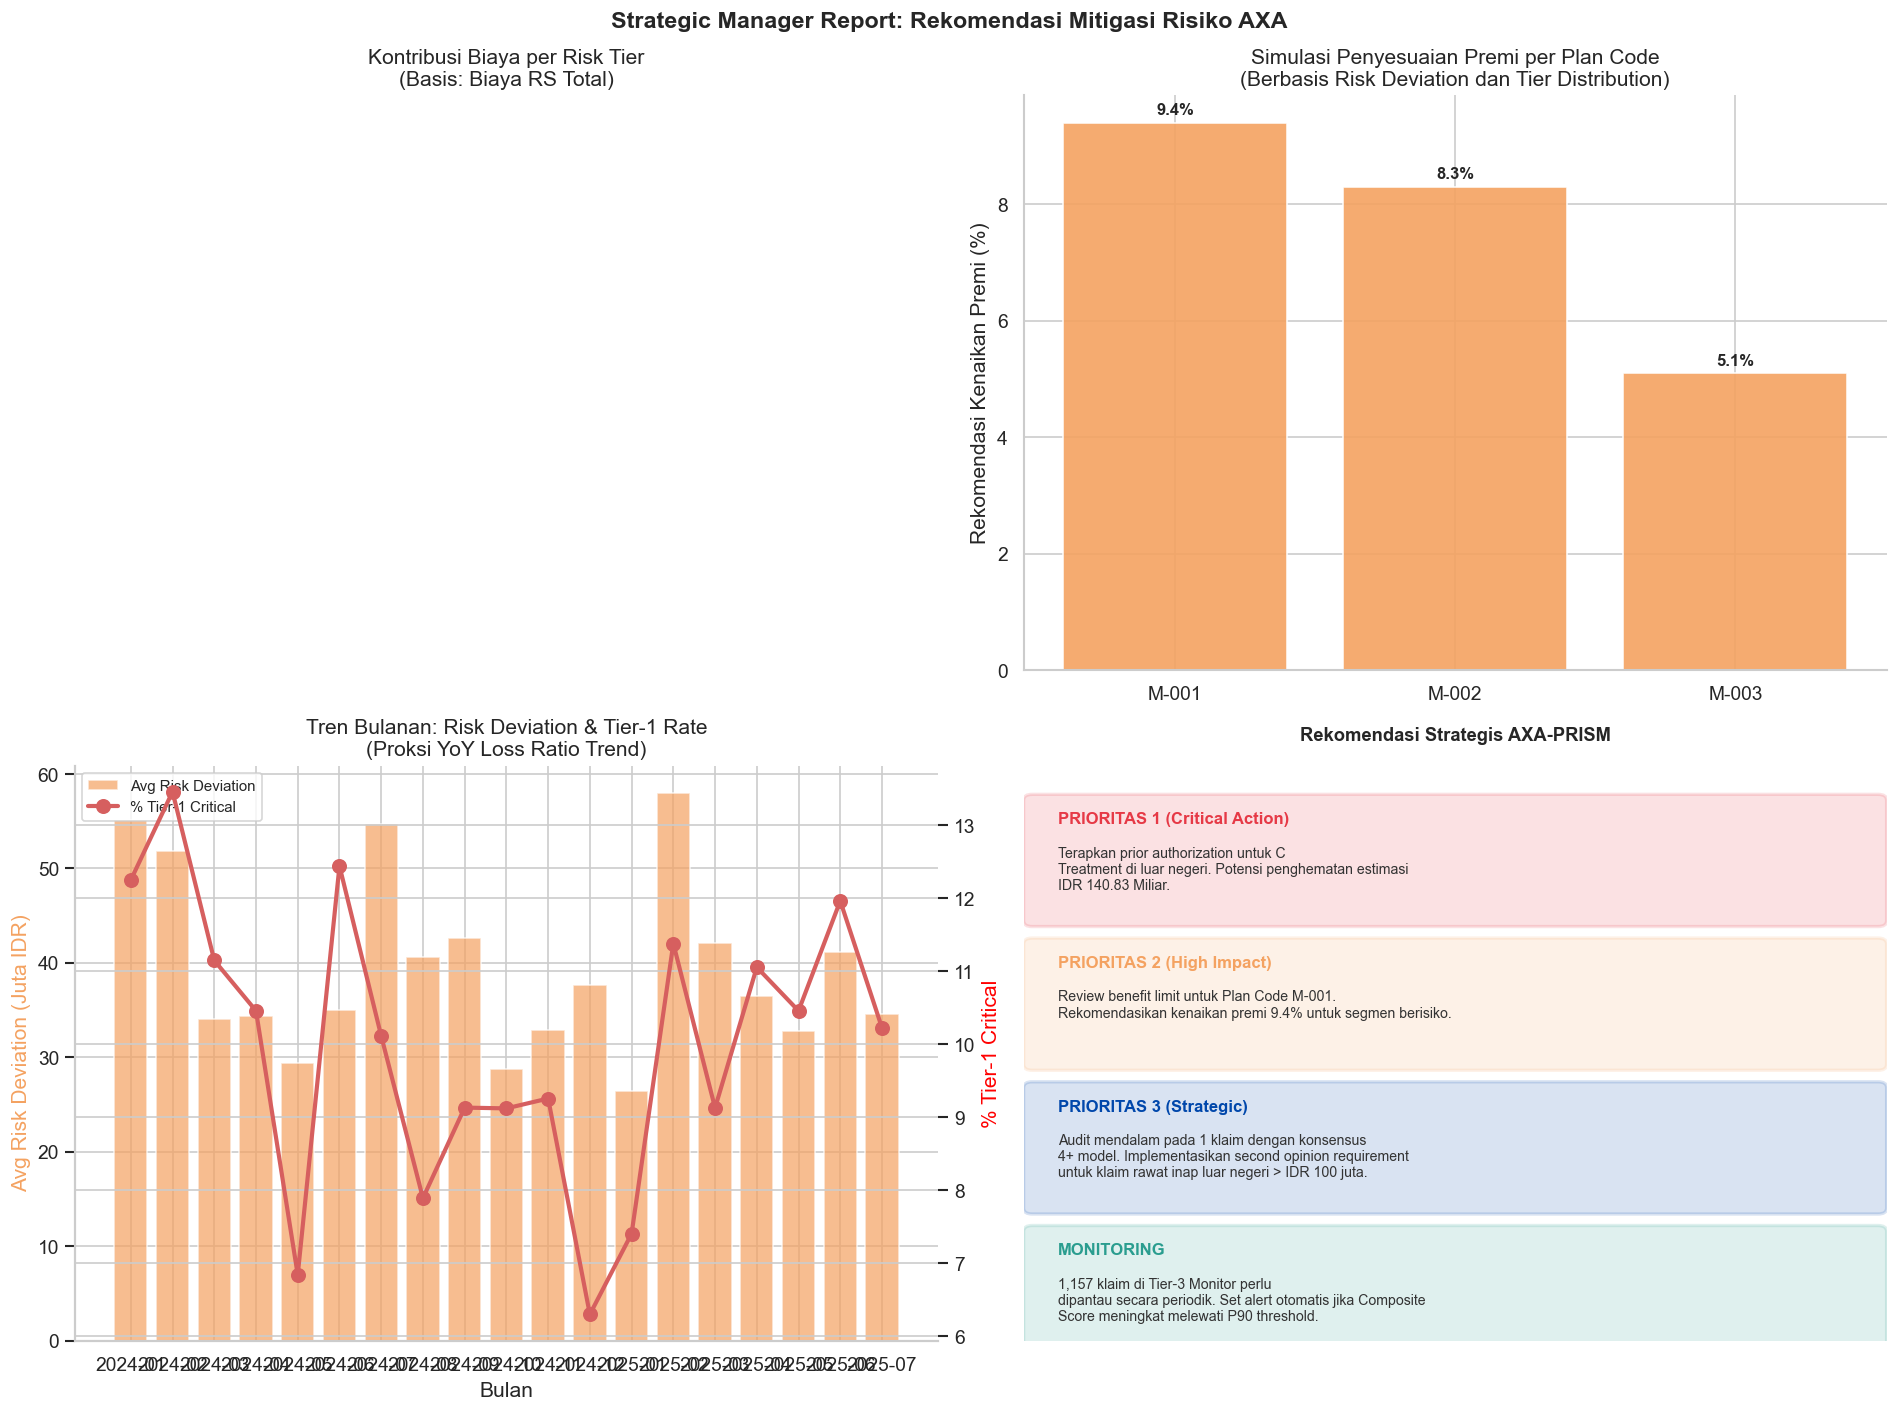


✅ AXA-PRISM Phase 2: Modeling & Decision Engine selesai sepenuhnya.
   Semua output tersedia untuk Data Operator, Risk Analyst, Medical Auditor,
   dan Strategic Manager.


In [40]:
# ================================================================
# SEL 9D: DASHBOARD - STRATEGIC MANAGER
# Fokus: Rekomendasi kebijakan premi dan mitigasi strategis
# ================================================================

print("=" * 70)
print("  STRATEGIC MANAGER REPORT: REKOMENDASI KEBIJAKAN AXA-PRISM")
print("=" * 70)

# Hitung Loss Ratio per segmen
df['Loss_Ratio'] = df[TARGET_REG] / df['Nominal Klaim Yang Disetujui'].replace(0, np.nan)

tier1_total_cost   = df[df['Is_Tier1']==1][TARGET_REG].sum()
tier1_pct_of_total = tier1_total_cost / df[TARGET_REG].sum()
overseas_pct_cost  = df[df['Is_Overseas']==1][TARGET_REG].sum() / df[TARGET_REG].sum()

print(f"\nTemuan Utama SPK AXA-PRISM:")
print(f"  1. Klaim Tier-1 Critical ({df['Is_Tier1'].mean()*100:.1f}% volume)")
print(f"     menyumbang {tier1_pct_of_total*100:.1f}% total biaya RS")
print(f"  2. Klaim Luar Negeri ({df['Is_Overseas'].mean()*100:.1f}% volume)")
print(f"     menyumbang {overseas_pct_cost*100:.1f}% total biaya RS")
print(f"  3. Kategori ICD berisiko tinggi: {df[df['Is_Tier1']==1]['ICD_Category'].value_counts().index[0]}")
print(f"     dengan rata-rata Risk Deviation IDR {df[df['Is_Tier1']==1]['Risk_Deviation'].mean()/1e6:.1f}M per klaim")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Strategic Manager Report: Rekomendasi Mitigasi Risiko AXA',
             fontweight='bold', fontsize=14)

# Panel 1: Cost Contribution oleh Risk Tier
tier_cost = df.groupby('Risk_Tier').agg(
    Total_Cost=(TARGET_REG, 'sum'),
    N=('Claim ID', 'count')
).reset_index()
tier_cost['Cost_Share'] = tier_cost['Total_Cost'] / tier_cost['Total_Cost'].sum() * 100
tier_order_cost = ['Tier-1 Critical', 'Tier-2 High Risk', 'Tier-3 Monitor', 'Normal']
tier_cost = tier_cost.set_index('Risk_Tier').reindex(
    [t for t in tier_order_cost if t in tier_cost.index]
).reset_index()
wedge_colors = [tier_colors.get(t, '#cccccc') for t in tier_cost['Risk_Tier']]
axes[0][0].pie(
    tier_cost['Cost_Share'],
    labels=[f"{row['Risk_Tier']} ({row['Cost_Share']:.1f}%)" for _, row in tier_cost.iterrows()],
    colors=wedge_colors,
    startangle=90, pctdistance=0.75
)
axes[0][0].set_title('Kontribusi Biaya per Risk Tier\n(Basis: Biaya RS Total)')

# Panel 2: Rekomendasi Penyesuaian Premi per Plan Code
plan_risk = df.groupby('Plan Code').agg(
    Loss_Ratio=('Loss_Ratio', 'mean'),
    Pct_Tier1=('Is_Tier1', 'mean'),
    Avg_Dev_Pct=('Risk_Deviation_Pct', 'mean')
).reset_index()
plan_risk['Rekomendasi_Penyesuaian_Premi_Pct'] = (
    plan_risk['Pct_Tier1'] * 15 +  # 15% premium loading per 1% tier1 ratio
    np.maximum(plan_risk['Avg_Dev_Pct'] * 0.1, 0)  # Additional loading untuk deviasi positif
).round(1)

bar_colors_plan = [
    COLOR_PALETTE['danger'] if v > 10 else COLOR_PALETTE['warning'] if v > 5 else COLOR_PALETTE['success']
    for v in plan_risk['Rekomendasi_Penyesuaian_Premi_Pct']
]
bars_plan = axes[0][1].bar(
    plan_risk['Plan Code'],
    plan_risk['Rekomendasi_Penyesuaian_Premi_Pct'],
    color=bar_colors_plan, edgecolor='white', alpha=0.9
)
axes[0][1].set_ylabel('Rekomendasi Kenaikan Premi (%)')
axes[0][1].set_title('Simulasi Penyesuaian Premi per Plan Code\n(Berbasis Risk Deviation dan Tier Distribution)')
axes[0][1].bar_label(bars_plan, fmt='%.1f%%', padding=3, fontsize=10, fontweight='bold')

# Panel 3: Trend Risk Deviation per Month (Loss Ratio Trend)
monthly_trend = df.groupby('Month_Claim').agg(
    Avg_Dev=('Risk_Deviation', 'mean'),
    Total_Cost=(TARGET_REG, 'sum'),
    Pct_Tier1=('Is_Tier1', 'mean')
).reset_index()
ax_m = axes[1][0]
ax_m2 = ax_m.twinx()
ax_m.bar(monthly_trend['Month_Claim'], monthly_trend['Avg_Dev']/1e6,
         color=COLOR_PALETTE['warning'], alpha=0.7, label='Avg Risk Deviation')
ax_m2.plot(monthly_trend['Month_Claim'], monthly_trend['Pct_Tier1']*100,
           'r-o', linewidth=2.5, markersize=8, label='% Tier-1 Critical')
ax_m.set_xlabel('Bulan')
ax_m.set_ylabel('Avg Risk Deviation (Juta IDR)', color=COLOR_PALETTE['warning'])
ax_m2.set_ylabel('% Tier-1 Critical', color='red')
ax_m.set_title('Tren Bulanan: Risk Deviation & Tier-1 Rate\n(Proksi YoY Loss Ratio Trend)')
ax_m.axhline(0, color='black', linewidth=1)

lines1, labels1 = ax_m.get_legend_handles_labels()
lines2, labels2 = ax_m2.get_legend_handles_labels()
ax_m.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

# Panel 4: Matriks Rekomendasi Strategis (Ringkasan Teks Visual)
ax4 = axes[1][1]
ax4.axis('off')
recommendations = [
    ("PRIORITAS 1 (Critical Action)", COLOR_PALETTE['danger'],
    f"Terapkan prior authorization untuk {df[df['Is_Tier1']==1]['ICD_Category'].value_counts().index[0]}\n"
     f"Treatment di luar negeri. Potensi penghematan estimasi\n"
     f"IDR {df[df['Is_Tier1']==1][df[df['Is_Tier1']==1]['Risk_Deviation']>0]['Risk_Deviation'].sum()/1e9:.2f} Miliar."),
    ("PRIORITAS 2 (High Impact)", COLOR_PALETTE['warning'],
     f"Review benefit limit untuk Plan Code {plan_risk.loc[plan_risk['Rekomendasi_Penyesuaian_Premi_Pct'].idxmax(), 'Plan Code']}.\n"
     f"Rekomendasikan kenaikan premi {plan_risk['Rekomendasi_Penyesuaian_Premi_Pct'].max():.1f}% untuk segmen berisiko."),
    ("PRIORITAS 3 (Strategic)", COLOR_PALETTE['primary'],
     f"Audit mendalam pada {(df['Model_Agreement_Count']>=4).sum():,} klaim dengan konsensus\n"
     f"4+ model. Implementasikan second opinion requirement\n"
     f"untuk klaim rawat inap luar negeri > IDR 100 juta."),
    ("MONITORING", COLOR_PALETTE['success'],
     f"{(df['Risk_Tier']=='Tier-3 Monitor').sum():,} klaim di Tier-3 Monitor perlu\n"
     f"dipantau secara periodik. Set alert otomatis jika Composite\n"
     f"Score meningkat melewati P90 threshold."),
]
y_pos = 0.95
for title, color, text in recommendations:
    rect = mpatches.FancyBboxPatch((0.01, y_pos-0.22), 0.98, 0.21,
                                    boxstyle="round,pad=0.01",
                                    facecolor=color, alpha=0.15,
                                    edgecolor=color, linewidth=2,
                                    transform=ax4.transAxes)
    ax4.add_patch(rect)
    ax4.text(0.04, y_pos - 0.03, title, transform=ax4.transAxes,
             fontsize=10, fontweight='bold', color=color, va='top')
    ax4.text(0.04, y_pos - 0.09, text, transform=ax4.transAxes,
             fontsize=8.5, va='top', color='#333333')
    y_pos -= 0.25

ax4.set_title('Rekomendasi Strategis AXA-PRISM', fontweight='bold', fontsize=11, pad=15)
plt.tight_layout()
plt.show()

print("\n✅ AXA-PRISM Phase 2: Modeling & Decision Engine selesai sepenuhnya.")
print("   Semua output tersedia untuk Data Operator, Risk Analyst, Medical Auditor,")
print("   dan Strategic Manager.")

---
## Ringkasan Arsitektur dan Keputusan Teknis AXA-PRISM 

### Arsitektur Hybrid AI + Expert System

**Lapisan 1: Expected Cost Engine (Regression)**
Random Forest / XGBoost dilatih pada fitur profil nasabah untuk menghasilkan
standar biaya yang "seharusnya". Ini adalah fondasi dari logika Expected vs Actual Cost.

**Lapisan 2: Anomaly Detection (Isolation Forest)**
Mendeteksi klaim yang menyimpang secara statistik dari pola normal dalam ruang
multidimensi fitur biaya dan perilaku klaim.

**Lapisan 3: Risk Segmentation (K-Means)**
Mengelompokkan nasabah ke segmen homogen untuk identifikasi root cause struktural
dari kenaikan biaya, bukan hanya deteksi kasus individual.

**Lapisan 4: Expert System Komparator**
Forward Chaining (rule-based facts), Backward Chaining (goal-driven audit), Naive
Bayes (probabilistic evidence), dan Certainty Factors (uncertainty handling) bekerja
sebagai validasi silang terhadap model AI.

**Lapisan 5: Dynamic Percentile Scoring**
Composite Risk Score dari bobot ke-5 model di-ranking menggunakan persentil distribusi
aktual, menghasilkan klasifikasi Tier yang adaptif dan tidak perlu kalibrasi ulang manual.

### Keunggulan Pendekatan Komparatif
Klaim yang teridentifikasi sebagai anomali oleh 4 atau lebih model memiliki tingkat
kepercayaan investigasi yang jauh lebih tinggi, mengurangi false positive dan
membantu tim audit medis memfokuskan sumber daya secara efisien.

---
*Fase berikutnya: Deployment sebagai API dan integrasi ke sistem operasional AXA.*